# %% [markdown]

 -*- coding: utf-8 -*-  <br>
 MBA Data Science e Analytics USP/ESALQ <br>
 Código para o desenvolvimento do TCC - Parte 02 <br>
 Autor: Ronaldo do Couto Silva Filho

# %% [markdown]


 ### 4. Aplicação de Técnicas de Machine Learning
 Aplicar técnicas de Machine Learning para Analisar dados e fazer previsões,
 validações e testes serão realizados na sequencia sem a devida separação em
 tópicos

In [ ]:
#%% In[0]: Importação de Pacotes

import os
import random
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from time import time
from utils import formatar_grafico_mbausp, read_parquet_with_source
from pprint import pprint

In [ ]:
# %% In[1]: Definir a seed para reprodutibilidade

seed = 0
np.random.seed(seed)
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

# %% [markdown]


 A partir desse ponto todo o código será desenvolvido para apenas uma cripto e
 um tamanho de base (resample), a alteração da base de dados em parquet se faz
 necessária para treinar os modelos nos respectivos casos.

In [ ]:
# %% In[2]: Carregar a Base de Dados

# Nesse momento carrega-se a base de dados a ser analisada

# # 30 min
# df = read_parquet_with_source("databases_parquet/sol_30min")
# df = read_parquet_with_source("databases_parquet/eth_30min")

# # 1 hora
df = read_parquet_with_source("databases_parquet/sol_1hr")
# df = read_parquet_with_source("databases_parquet/eth_1hr")

# # 1 dia
# df = read_parquet_with_source("databases_parquet/sol_1dia")
# df = read_parquet_with_source("databases_parquet/eth_1dia")

In [ ]:
# %% In[15]: Segregar o dataset em dados de treino e teste

def segrega_data_set(df, target='close', prop_treino=0.8):
    # Proporções
    train_size = int(len(df) * prop_treino)  

    # Divisão em treino e teste
    train = df[:train_size]
    test = df[train_size:]

    # Verificando as divisões
    print(f'Tamanho treino: {len(train)}, teste: {len(test)}')

    # Separa os atributos (X) e o alvo (y)
    X_train, y_train = train.drop(columns=[target]), train[target]
    X_test, y_test = test.drop(columns=[target]), test[target]

    return X_train, y_train, X_test, y_test, test

X_train, y_train, X_test, y_test, test = segrega_data_set(df)

Tamanho treino: 30439, teste: 7610


In [ ]:
# %% In[16]: Aplicar a normalização dos dados de treino do modelo

def normaliza_treino(X_train, X_test):

    # Escalonar apenas o conjunto de treino
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # Usar o mesmo escalador nos outros conjuntos
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled

X_train_scaled, X_test_scaled = normaliza_treino(X_train, X_test)

# ------------------------------------------------------------------------------------------------ #

In [ ]:
# %% In[17]: Aplicar o Algoritmoo Naive, considerando para esse algoritmo

# o ultimo valor presente no conjunto de validação

# Criando dicionário para salvar os resultados:
results = {}

def modela_Naive(df):
    # Tempo inicial
    start_time = time()

    # Criando a coluna de valores previstos
    test['predicted_naive']=test['close'][0]

    # Copiando o primeiro valor real do conjunto de teste para valores previstos
    test['predicted_naive'][0]=test['close'][0]

    # Calcular o erro (exemplo: MAE)
    mae = mean_absolute_error(test['close'].iloc[1:], 
                              test['predicted_naive'].iloc[1:])

    mse = mean_squared_error(test['close'].iloc[1:], 
                                            test['predicted_naive'].iloc[1:])

    rmse = np.sqrt(mse)

    # Calculo de Tempo de Execução
    end_time = time()
    execution_time = end_time - start_time

    metricas_benchmark = [mae, mse, rmse, 'NA', execution_time]

    # Nome dinâmico da variável, ex: "sol_1dia_Naive"
    var_name = f"{df.attrs['source']}_Naive"

    # Cria um campo no dicionário results com nome de acordo com o df em estudo
    results[var_name] = metricas_benchmark

    print(f'MAE_test do Benchmark: {mae: .2f}')
    print(f'MSE_test do Benchmark: {mse: .2f}')
    print(f'RMSE_test do Benchmark: {rmse: .2f}')
    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    # opcional: também retornar
    return metricas_benchmark

metricas_benchmark = modela_Naive(df)

MAE_test do Benchmark:  64.59
MSE_test do Benchmark:  5300.21
RMSE_test do Benchmark:  72.80
O tempo que o modelo levou para treinar foi de: 0.003000497817993164


<ipython-input-6-491578c6e6f1>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test['predicted_naive']=test['close'][0]
<ipython-input-6-491578c6e6f1>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['predicted_naive']=test['close'][0]
<ipython-input-6-491578c6e6f1>:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test['predicted_naive'][0]=test['close'][0]
<ipython-in

# %% [markdown]

 ### Modelagem
 A partir desse momento serão apresentados os algoritmos a serem utilizados
 nesse estudo. <br>

 #### 1. Random Forest

In [ ]:
# %% In[18]: Aplicar o Algoritmo de Random Forest: 1º Regularização

def RF_simple_funcion(X_train_scaled = X_train_scaled, y_train = y_train, 
              X_test_scaled = X_test_scaled, y_test = y_test, 
              mae_bench = metricas_benchmark[0]):
    """
    Hiperparâmetros utilizados para o Modelo de RF utilizado:
    Parametros = n_estimators=300, random_state=42, criterion='squared_error',
                 n_jobs=-1)
    
    rf_model = RandomForestRegressor(n_estimators=300, 
                                    random_state=42,
                                    criterion='squared_error',
                                    n_jobs=-1)
    """
    
    # Inicia a contagem de tempo para rodar o modelo:
    start_time = time()

    # Modelo Random Forest
    rf_model = RandomForestRegressor(n_estimators=300, 
                                    random_state=42,
                                    criterion='squared_error',
                                    n_jobs=-1)

    # Treinamento
    rf_model.fit(X_train_scaled, y_train)

    # Finaliza o Tempo de Execução
    end_time = time()
    execution_time = end_time - start_time

    # — Avaliação do modelo no conjunto de TREINO —
    y_train_pred = rf_model.predict(X_train_scaled)

    mae_rf_train = mean_absolute_error(y_train, y_train_pred)
    mse_rf_train = mean_squared_error(y_train, y_train_pred)
    rmse_rf_train= np.sqrt(mae_rf_train)
    mase_rf_train= mean_absolute_error(y_train, y_train_pred)/mae_bench
    execution_time = end_time - start_time

    results_RF_train = [mae_rf_train, mse_rf_train,
                        rmse_rf_train, mase_rf_train, execution_time]

    print(
        "Resultados das métricas para o modelo de RF com dados de treino são: ")
    pprint(results_RF_train)
    print()

    # Nome dinâmico da variável, ex: "sol_1dia_RF_train"
    var_name = f"{df.attrs['source']}_RF_train"

    # Cria um campo no dicionário results com nome de acordo com o df em estudo
    results[var_name] = results_RF_train

    # Previsão no conjunto de teste
    y_test_pred = rf_model.predict(X_test_scaled)

    # Avaliação no conjunto de teste
    mae_rf_test = mean_absolute_error(y_test, y_test_pred)
    mse_rf_test = mean_squared_error(y_test, y_test_pred)
    rmse_rf_test = np.sqrt(mse_rf_test)

    # Calculo do incicador MASE
    mase_rf_test = mae_rf_test/mae_bench

    results_RF_test = [mae_rf_test, mse_rf_test, rmse_rf_test, mase_rf_test,
                    execution_time]

    print("Resultados das métricas para o modelo de RF com dados de teste são: ")
    pprint(results_RF_test)

    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    # Salvando o resultado das métricas na respectiva variável
    var_name = f"{df.attrs['source']}_RF_teste"
    results[var_name] = results_RF_test

    return y_test_pred

y_test_pred_RF = RF_simple_funcion()

Resultados das métricas para o modelo de RF com dados de treino são: 
[0.11547336625254218,
 0.06221083449446615,
 np.float64(0.3398137228726088),
 0.0017878888485996598,
 6.332820177078247]

Resultados das métricas para o modelo de RF com dados de teste são: 
[1.012037833541574,
 1.9815763924996639,
 np.float64(1.4076847631837406),
 0.015669510776993602,
 6.332820177078247]
O tempo que o modelo levou para treinar foi de: 6.332820177078247


In [ ]:
#%% In[19]: Random Forest com GridSearch

def RF_GridSearch_function(X_train_scaled = X_train_scaled, y_train = y_train):

    start_time = time()

    param_grid = {
        "n_estimators": [100, 300, 500, 1000], # [100, 200, 400, 800, 1000]
        "max_features": ["sqrt", None], # Como sqrt(4)=log2(4), não usado
        "max_depth": [10, 20, 100, None], # [5, 10, 20, 40, 80, 100]
        "min_samples_leaf":[5,10], 
        }

    rf_model = RandomForestRegressor(random_state=42)

    grid_search = GridSearchCV(estimator=rf_model, 
                            param_grid=param_grid, 
                            scoring='neg_root_mean_squared_error', 
                            cv=4, 
                            n_jobs=-1)

    grid_search.fit(X_train_scaled, y_train.values)

    end_time = time()
    execution_time = end_time - start_time

    # Print the best parameters and the best score
    print(grid_search)
    print(grid_search.best_params_)
    print(grid_search.best_score_)

    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    print(grid_search.best_params_['max_depth'],
        grid_search.best_params_['max_features'], 
        grid_search.best_params_['min_samples_leaf'], 
        grid_search.best_params_['n_estimators'])
    
    return grid_search

grid_search = RF_GridSearch_function()

# Salvando em um dicionário os melhores parâmetros
best_RF_dict = {}
var_name = f"{df.attrs['source']}_best_RF_params"
best_RF_dict[var_name] = grid_search.best_params_

GridSearchCV(cv=4, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 100, None],
                         'max_features': ['sqrt', None],
                         'min_samples_leaf': [5, 10],
                         'n_estimators': [100, 300, 500, 1000]},
             scoring='neg_root_mean_squared_error')
{'max_depth': 20, 'max_features': None, 'min_samples_leaf': 5, 'n_estimators': 100}
-12.886953219034252
O tempo que o modelo levou para treinar foi de: 739.5355699062347
20 None 5 100


In [ ]:
#%% In[20]: Rodando o melhor modelo (best_RF)

def best_RF_function(X_train_scaled=X_train_scaled,y_train=y_train,
            mae_bench=metricas_benchmark[0],
            grid_search=grid_search):

    start_time = time()

    best_rf_model = RandomForestRegressor(
                n_estimators = grid_search.best_params_['n_estimators'],
                max_features = grid_search.best_params_['max_features'],
                max_depth = grid_search.best_params_['max_depth'],
                min_samples_leaf = grid_search.best_params_['min_samples_leaf'],
                random_state = 42,
                n_jobs = -1)

    best_rf_model.fit(X_train_scaled, y_train.values)

    end_time = time()
    execution_time = end_time - start_time
    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    # Previsão no conjunto de treino
    y_train_pred = best_rf_model.predict(X_train_scaled)

    # Avaliação no conjunto de teste
    mae_rf_train = mean_absolute_error(y_train, y_train_pred)
    mse_rf_train = mean_squared_error(y_train, y_train_pred)
    rmse_rf_train = np.sqrt(mse_rf_train)
    mase_rf_train = mae_rf_train/mae_bench

    # Salvando valores de treino
    results_best_RF_train = [mae_rf_train, mse_rf_train, rmse_rf_train,
                         mase_rf_train, execution_time]

    var_name = f"{df.attrs['source']}_best_RF_train"
    results[var_name] = results_best_RF_train
    
    print("Resultados das métricas para o melhor modelo de RF com dados " \
        "de treino são: ")
    pprint(results_best_RF_train)
    print()
    

    # Previsão no conjunto de teste
    y_test_pred = best_rf_model.predict(X_test_scaled)

    # Avaliação no conjunto de teste
    mae_rf_test = mean_absolute_error(y_test, y_test_pred)
    mse_rf_test = mean_squared_error(y_test, y_test_pred)
    rmse_rf_test = np.sqrt(mse_rf_test)
    mase_rf_test = mae_rf_test/mae_bench

    # Salvando valores de treino
    results_best_RF_test = [mae_rf_test, mse_rf_test, rmse_rf_test,
                         mase_rf_test, execution_time]
    
    var_name = f"{df.attrs['source']}_best_RF_test"
    results[var_name] = results_best_RF_test
    
    print("Resultados das métricas para o melhor modelo de RF com dados " \
        "de teste são: ")
    pprint(results_best_RF_test)
    print()

    return y_test_pred, y_train_pred

y_test_pred_best_RF,  y_train_pred_best_RF= best_RF_function()

O tempo que o modelo levou para treinar foi de: 1.7091269493103027
Resultados das métricas para o melhor modelo de RF com dados de treino são: 
[0.23254132001233122,
 0.2663527117802166,
 np.float64(0.5160937044570653),
 0.0036004668988294853,
 1.7091269493103027]

Resultados das métricas para o melhor modelo de RF com dados de teste são: 
[1.034608744092888,
 2.027729668414157,
 np.float64(1.423983731794067),
 0.016018979062080045,
 1.7091269493103027]



# %% [markdown]

 # 6. Interpretação dos Resultados:

Gráfico salvo como: graficos\sol_1hr_Naive_forecast.jpg


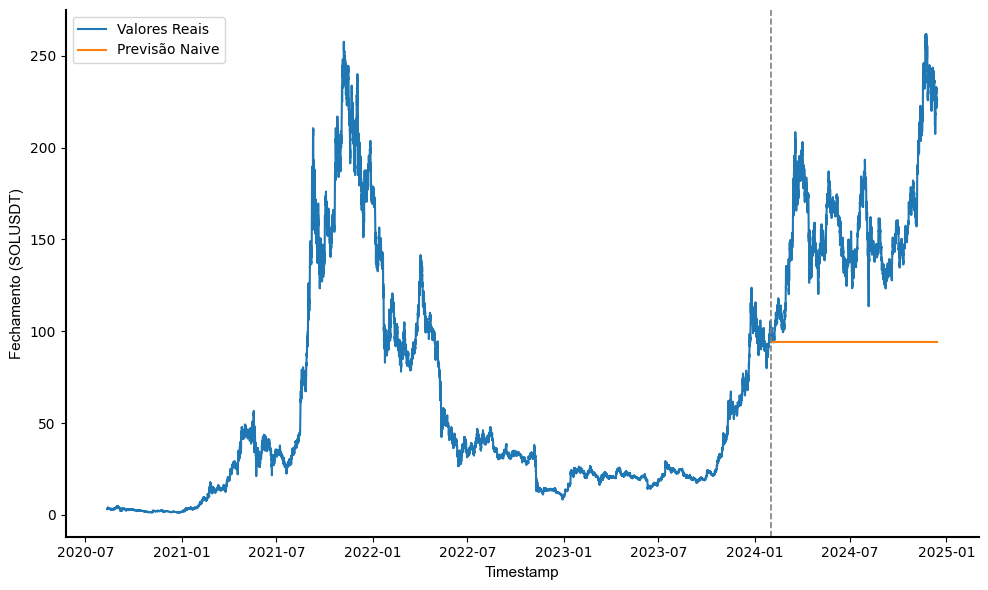

Gráfico salvo como: graficos\sol_1hr_RF_forecast.jpg


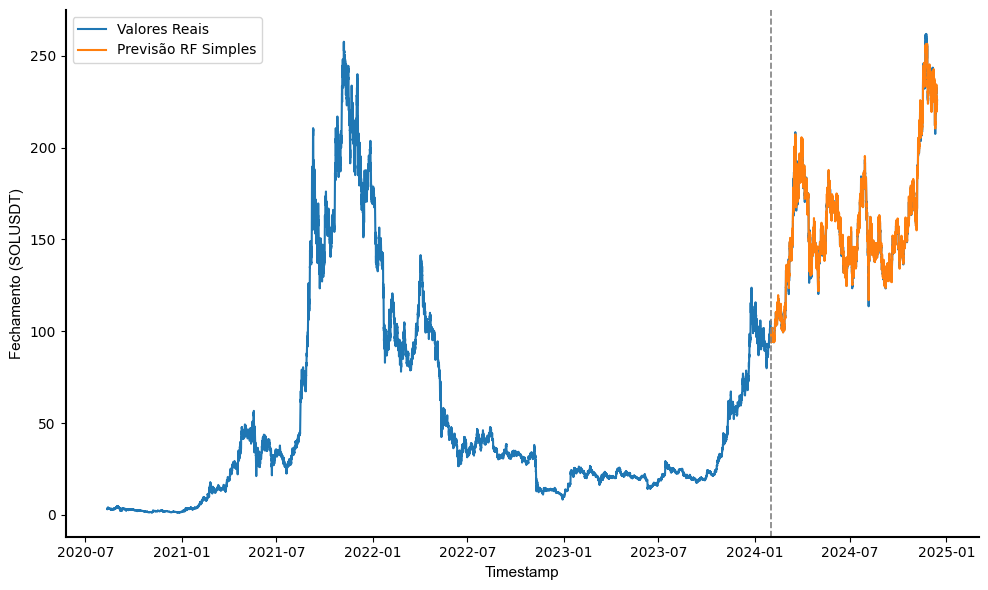

Gráfico salvo como: graficos\sol_1hr_best_RF_forecast.jpg


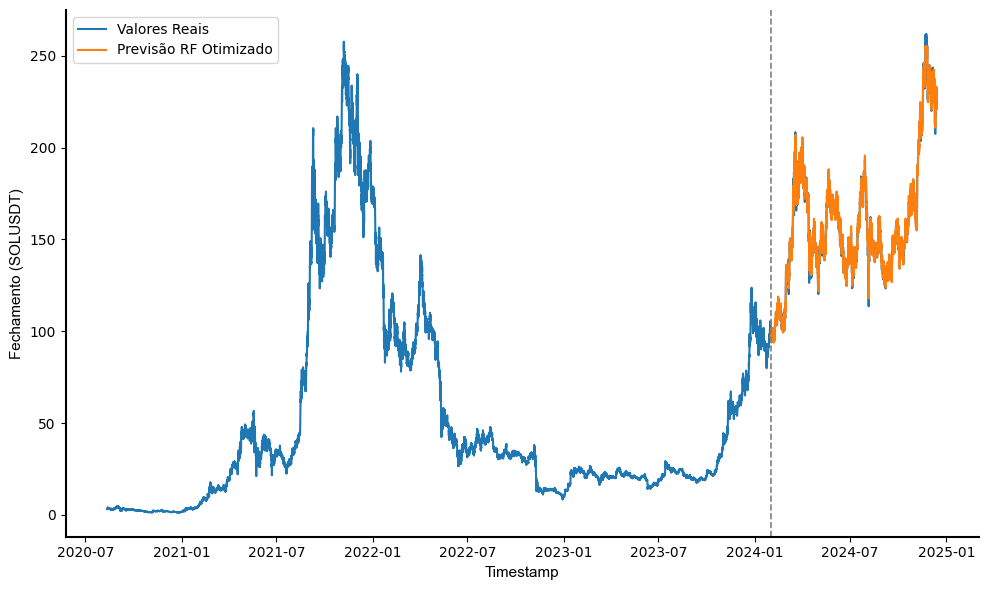

In [ ]:
# %% In[21]: Visualizando os resultados do modelo:

# 1. Vizualizar resultados de Naive

# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_test])
y_pred = pd.concat([
    # pd.Series(y_train),
    pd.Series(test["predicted_naive"], index=test.index)
])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão Naive": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_Naive_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    cores = ["blue", "orange"],
    legenda = True,
    vertical = True
)

# 2. Vizualizar resultados de RF

# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_test])
y_pred = pd.concat([
    # pd.Series(y_train),
    pd.Series(y_test_pred_RF, index=y_test.index)
])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão RF Simples": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_RF_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    cores = ["blue", "orange"],
    legenda = True,
    vertical = True
)

# 3. Vizualizar resultados de best RF
 
# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_test])
y_pred = pd.concat([
    # pd.Series(y_train),
    pd.Series(y_test_pred_best_RF, index=y_test.index)
])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão RF Otimizado": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_best_RF_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    cores = ["blue", "orange"],
    legenda = True,
    vertical = True
)

In [ ]:
# %% In[22]: Salvando os resultados obtidos:

os.makedirs("Resultados_Naive_RF", exist_ok=True)
caminho_results = os.path.join("Resultados_Naive_RF", f"Naive_RF-{df.attrs['source']}.csv")

arquivo = pd.DataFrame(results)
arquivo.to_csv(caminho_results, index = False)

caminho_param = os.path.join("Resultados_Naive_RF", f"Best_param-{df.attrs['source']}.csv")
best_hiperpar = pd.DataFrame(best_RF_dict)
best_hiperpar.to_csv(caminho_param, index = False)

# %% [markdown]

 -*- coding: utf-8 -*-  <br>
 MBA Data Science e Analytics USP/ESALQ <br>
 Código para o desenvolvimento do TCC - Parte 02 <br>
 Autor: Ronaldo do Couto Silva Filho

# %% [markdown]


 ### 4. Aplicação de Técnicas de Machine Learning
 Aplicar técnicas de Machine Learning para Analisar dados e fazer previsões,
 validações e testes serão realizados na sequencia sem a devida separação em
 tópicos

In [ ]:
#%% In[0]: Importação de Pacotes

import os
import random
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from time import time
from utils import formatar_grafico_mbausp, read_parquet_with_source
from pprint import pprint

In [ ]:
# %% In[1]: Definir a seed para reprodutibilidade

seed = 0
np.random.seed(seed)
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

# %% [markdown]


 A partir desse ponto todo o código será desenvolvido para apenas uma cripto e
 um tamanho de base (resample), a alteração da base de dados em parquet se faz
 necessária para treinar os modelos nos respectivos casos.

In [ ]:
# %% In[2]: Carregar a Base de Dados

# Nesse momento carrega-se a base de dados a ser analisada

# # 30 min
# df = read_parquet_with_source("databases_parquet/sol_30min")
# df = read_parquet_with_source("databases_parquet/eth_30min")

# # 1 hora
# df = read_parquet_with_source("databases_parquet/sol_1hr")
df = read_parquet_with_source("databases_parquet/eth_1hr")

# # 1 dia
# df = read_parquet_with_source("databases_parquet/sol_1dia")
# df = read_parquet_with_source("databases_parquet/eth_1dia")

In [ ]:
# %% In[15]: Segregar o dataset em dados de treino e teste

def segrega_data_set(df, target='close', prop_treino=0.8):
    # Proporções
    train_size = int(len(df) * prop_treino)  

    # Divisão em treino e teste
    train = df[:train_size]
    test = df[train_size:]

    # Verificando as divisões
    print(f'Tamanho treino: {len(train)}, teste: {len(test)}')

    # Separa os atributos (X) e o alvo (y)
    X_train, y_train = train.drop(columns=[target]), train[target]
    X_test, y_test = test.drop(columns=[target]), test[target]

    return X_train, y_train, X_test, y_test, test

X_train, y_train, X_test, y_test, test = segrega_data_set(df)

Tamanho treino: 51352, teste: 12839


In [ ]:
# %% In[16]: Aplicar a normalização dos dados de treino do modelo

def normaliza_treino(X_train, X_test):

    # Escalonar apenas o conjunto de treino
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # Usar o mesmo escalador nos outros conjuntos
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled

X_train_scaled, X_test_scaled = normaliza_treino(X_train, X_test)

# ------------------------------------------------------------------------------------------------ #

In [ ]:
# %% In[17]: Aplicar o Algoritmoo Naive, considerando para esse algoritmo

# o ultimo valor presente no conjunto de validação

# Criando dicionário para salvar os resultados:
results = {}

def modela_Naive(df):
    # Tempo inicial
    start_time = time()

    # Criando a coluna de valores previstos
    test['predicted_naive']=test['close'][0]

    # Copiando o primeiro valor real do conjunto de teste para valores previstos
    test['predicted_naive'][0]=test['close'][0]

    # Calcular o erro (exemplo: MAE)
    mae = mean_absolute_error(test['close'].iloc[1:], 
                              test['predicted_naive'].iloc[1:])

    mse = mean_squared_error(test['close'].iloc[1:], 
                                            test['predicted_naive'].iloc[1:])

    rmse = np.sqrt(mse)

    # Calculo de Tempo de Execução
    end_time = time()
    execution_time = end_time - start_time

    metricas_benchmark = [mae, mse, rmse, 'NA', execution_time]

    # Nome dinâmico da variável, ex: "sol_1dia_Naive"
    var_name = f"{df.attrs['source']}_Naive"

    # Cria um campo no dicionário results com nome de acordo com o df em estudo
    results[var_name] = metricas_benchmark

    print(f'MAE_test do Benchmark: {mae: .2f}')
    print(f'MSE_test do Benchmark: {mse: .2f}')
    print(f'RMSE_test do Benchmark: {rmse: .2f}')
    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    # opcional: também retornar
    return metricas_benchmark

metricas_benchmark = modela_Naive(df)

MAE_test do Benchmark:  813.57
MSE_test do Benchmark:  1048939.68
RMSE_test do Benchmark:  1024.18
O tempo que o modelo levou para treinar foi de: 0.007416248321533203


<ipython-input-17-491578c6e6f1>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test['predicted_naive']=test['close'][0]
<ipython-input-17-491578c6e6f1>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['predicted_naive']=test['close'][0]
<ipython-input-17-491578c6e6f1>:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test['predicted_naive'][0]=test['close'][0]
<ipython

# %% [markdown]

 ### Modelagem
 A partir desse momento serão apresentados os algoritmos a serem utilizados
 nesse estudo. <br>

 #### 1. Random Forest

In [ ]:
# %% In[18]: Aplicar o Algoritmo de Random Forest: 1º Regularização

def RF_simple_funcion(X_train_scaled = X_train_scaled, y_train = y_train, 
              X_test_scaled = X_test_scaled, y_test = y_test, 
              mae_bench = metricas_benchmark[0]):
    """
    Hiperparâmetros utilizados para o Modelo de RF utilizado:
    Parametros = n_estimators=300, random_state=42, criterion='squared_error',
                 n_jobs=-1)
    
    rf_model = RandomForestRegressor(n_estimators=300, 
                                    random_state=42,
                                    criterion='squared_error',
                                    n_jobs=-1)
    """
    
    # Inicia a contagem de tempo para rodar o modelo:
    start_time = time()

    # Modelo Random Forest
    rf_model = RandomForestRegressor(n_estimators=300, 
                                    random_state=42,
                                    criterion='squared_error',
                                    n_jobs=-1)

    # Treinamento
    rf_model.fit(X_train_scaled, y_train)

    # Finaliza o Tempo de Execução
    end_time = time()
    execution_time = end_time - start_time

    # — Avaliação do modelo no conjunto de TREINO —
    y_train_pred = rf_model.predict(X_train_scaled)

    mae_rf_train = mean_absolute_error(y_train, y_train_pred)
    mse_rf_train = mean_squared_error(y_train, y_train_pred)
    rmse_rf_train= np.sqrt(mae_rf_train)
    mase_rf_train= mean_absolute_error(y_train, y_train_pred)/mae_bench
    execution_time = end_time - start_time

    results_RF_train = [mae_rf_train, mse_rf_train,
                        rmse_rf_train, mase_rf_train, execution_time]

    print(
        "Resultados das métricas para o modelo de RF com dados de treino são: ")
    pprint(results_RF_train)
    print()

    # Nome dinâmico da variável, ex: "sol_1dia_RF_train"
    var_name = f"{df.attrs['source']}_RF_train"

    # Cria um campo no dicionário results com nome de acordo com o df em estudo
    results[var_name] = results_RF_train

    # Previsão no conjunto de teste
    y_test_pred = rf_model.predict(X_test_scaled)

    # Avaliação no conjunto de teste
    mae_rf_test = mean_absolute_error(y_test, y_test_pred)
    mse_rf_test = mean_squared_error(y_test, y_test_pred)
    rmse_rf_test = np.sqrt(mse_rf_test)

    # Calculo do incicador MASE
    mase_rf_test = mae_rf_test/mae_bench

    results_RF_test = [mae_rf_test, mse_rf_test, rmse_rf_test, mase_rf_test,
                    execution_time]

    print("Resultados das métricas para o modelo de RF com dados de teste são: ")
    pprint(results_RF_test)

    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    # Salvando o resultado das métricas na respectiva variável
    var_name = f"{df.attrs['source']}_RF_teste"
    results[var_name] = results_RF_test

    return y_test_pred

y_test_pred_RF = RF_simple_funcion()

Resultados das métricas para o modelo de RF com dados de treino são: 
[1.8261496398913253,
 15.482190469971137,
 np.float64(1.3513510424354307),
 0.0022446105861685817,
 12.173213481903076]

Resultados das métricas para o modelo de RF com dados de teste são: 
[11.311644256326582,
 295.44356758449436,
 np.float64(17.188471938613226),
 0.013903699833839827,
 12.173213481903076]
O tempo que o modelo levou para treinar foi de: 12.173213481903076


In [ ]:
#%% In[19]: Random Forest com GridSearch

def RF_GridSearch_function(X_train_scaled = X_train_scaled, y_train = y_train):

    start_time = time()

    param_grid = {
        "n_estimators": [100, 300, 500, 1000], # [100, 200, 400, 800, 1000]
        "max_features": ["sqrt", None], # Como sqrt(4)=log2(4), não usado
        "max_depth": [10, 20, 100, None], # [5, 10, 20, 40, 80, 100]
        "min_samples_leaf":[5,10], 
        }

    rf_model = RandomForestRegressor(random_state=42)

    grid_search = GridSearchCV(estimator=rf_model, 
                            param_grid=param_grid, 
                            scoring='neg_root_mean_squared_error', 
                            cv=4, 
                            n_jobs=-1)

    grid_search.fit(X_train_scaled, y_train.values)

    end_time = time()
    execution_time = end_time - start_time

    # Print the best parameters and the best score
    print(grid_search)
    print(grid_search.best_params_)
    print(grid_search.best_score_)

    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    print(grid_search.best_params_['max_depth'],
        grid_search.best_params_['max_features'], 
        grid_search.best_params_['min_samples_leaf'], 
        grid_search.best_params_['n_estimators'])
    
    return grid_search

grid_search = RF_GridSearch_function()

# Salvando em um dicionário os melhores parâmetros
best_RF_dict = {}
var_name = f"{df.attrs['source']}_best_RF_params"
best_RF_dict[var_name] = grid_search.best_params_

GridSearchCV(cv=4, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 100, None],
                         'max_features': ['sqrt', None],
                         'min_samples_leaf': [5, 10],
                         'n_estimators': [100, 300, 500, 1000]},
             scoring='neg_root_mean_squared_error')
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
-83.17854880794901
O tempo que o modelo levou para treinar foi de: 1208.6373245716095
20 sqrt 5 100


In [ ]:
#%% In[20]: Rodando o melhor modelo (best_RF)

def best_RF_function(X_train_scaled=X_train_scaled,y_train=y_train,
            mae_bench=metricas_benchmark[0],
            grid_search=grid_search):

    start_time = time()

    best_rf_model = RandomForestRegressor(
                n_estimators = grid_search.best_params_['n_estimators'],
                max_features = grid_search.best_params_['max_features'],
                max_depth = grid_search.best_params_['max_depth'],
                min_samples_leaf = grid_search.best_params_['min_samples_leaf'],
                random_state = 42,
                n_jobs = -1)

    best_rf_model.fit(X_train_scaled, y_train.values)

    end_time = time()
    execution_time = end_time - start_time
    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    # Previsão no conjunto de treino
    y_train_pred = best_rf_model.predict(X_train_scaled)

    # Avaliação no conjunto de teste
    mae_rf_train = mean_absolute_error(y_train, y_train_pred)
    mse_rf_train = mean_squared_error(y_train, y_train_pred)
    rmse_rf_train = np.sqrt(mse_rf_train)
    mase_rf_train = mae_rf_train/mae_bench

    # Salvando valores de treino
    results_best_RF_train = [mae_rf_train, mse_rf_train, rmse_rf_train,
                         mase_rf_train, execution_time]

    var_name = f"{df.attrs['source']}_best_RF_train"
    results[var_name] = results_best_RF_train
    
    print("Resultados das métricas para o melhor modelo de RF com dados " \
        "de treino são: ")
    pprint(results_best_RF_train)
    print()
    

    # Previsão no conjunto de teste
    y_test_pred = best_rf_model.predict(X_test_scaled)

    # Avaliação no conjunto de teste
    mae_rf_test = mean_absolute_error(y_test, y_test_pred)
    mse_rf_test = mean_squared_error(y_test, y_test_pred)
    rmse_rf_test = np.sqrt(mse_rf_test)
    mase_rf_test = mae_rf_test/mae_bench

    # Salvando valores de treino
    results_best_RF_test = [mae_rf_test, mse_rf_test, rmse_rf_test,
                         mase_rf_test, execution_time]
    
    var_name = f"{df.attrs['source']}_best_RF_test"
    results[var_name] = results_best_RF_test
    
    print("Resultados das métricas para o melhor modelo de RF com dados " \
        "de teste são: ")
    pprint(results_best_RF_test)
    print()

    return y_test_pred, y_train_pred

y_test_pred_best_RF,  y_train_pred_best_RF= best_RF_function()

O tempo que o modelo levou para treinar foi de: 1.91420316696167
Resultados das métricas para o melhor modelo de RF com dados de treino são: 
[4.005747089571021,
 79.31954904542721,
 np.float64(8.906152314295282),
 0.004923661307022013,
 1.91420316696167]

Resultados das métricas para o melhor modelo de RF com dados de teste são: 
[11.532384137041923,
 294.7077736444484,
 np.float64(17.16705489140314),
 0.014175022107885633,
 1.91420316696167]



# %% [markdown]

 # 6. Interpretação dos Resultados:

Gráfico salvo como: graficos\eth_1hr_Naive_forecast.jpg


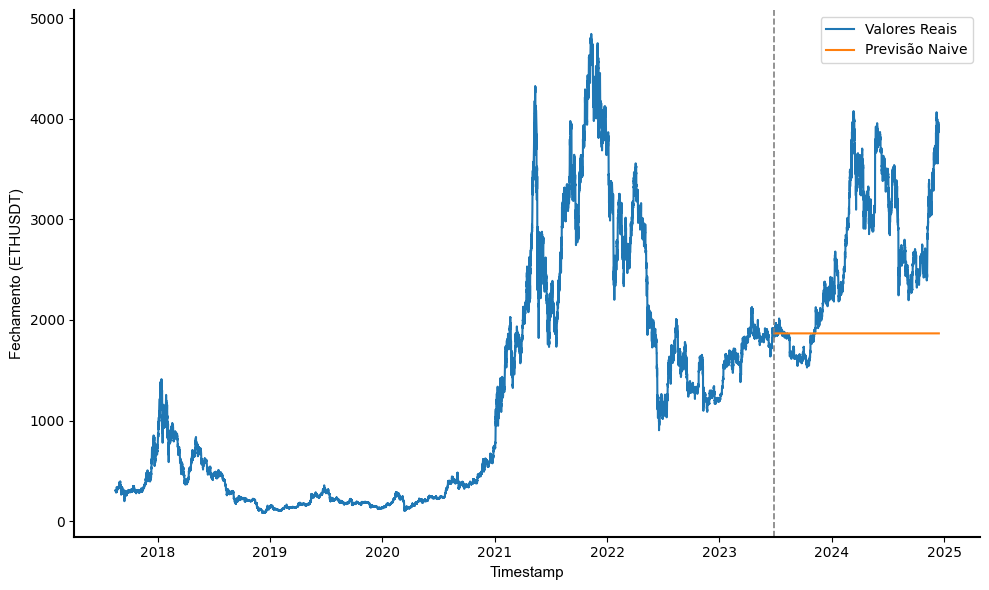

Gráfico salvo como: graficos\eth_1hr_RF_forecast.jpg


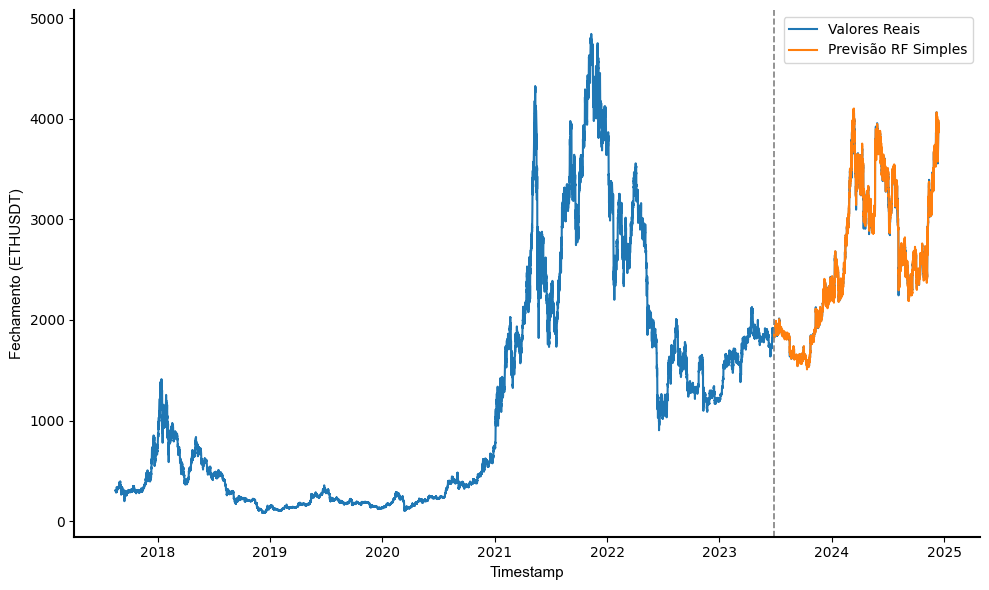

Gráfico salvo como: graficos\eth_1hr_best_RF_forecast.jpg


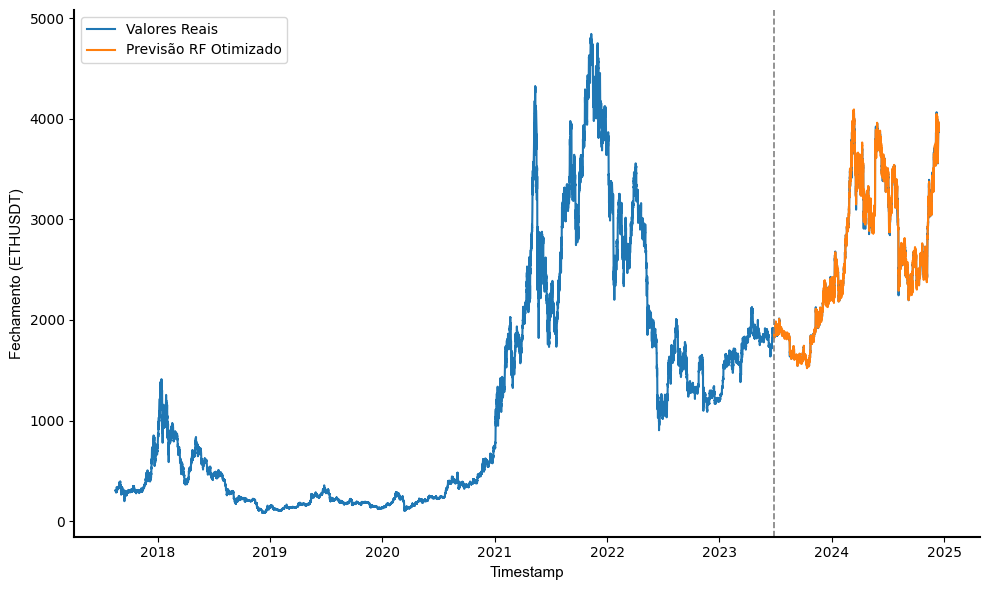

In [ ]:
# %% In[21]: Visualizando os resultados do modelo:

# 1. Vizualizar resultados de Naive

# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_test])
y_pred = pd.concat([
    # pd.Series(y_train),
    pd.Series(test["predicted_naive"], index=test.index)
])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão Naive": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_Naive_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    cores = ["blue", "orange"],
    legenda = True,
    vertical = True
)

# 2. Vizualizar resultados de RF

# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_test])
y_pred = pd.concat([
    # pd.Series(y_train),
    pd.Series(y_test_pred_RF, index=y_test.index)
])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão RF Simples": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_RF_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    cores = ["blue", "orange"],
    legenda = True,
    vertical = True
)

# 3. Vizualizar resultados de best RF
 
# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_test])
y_pred = pd.concat([
    # pd.Series(y_train),
    pd.Series(y_test_pred_best_RF, index=y_test.index)
])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão RF Otimizado": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_best_RF_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    cores = ["blue", "orange"],
    legenda = True,
    vertical = True
)

In [ ]:
# %% In[22]: Salvando os resultados obtidos:

os.makedirs("Resultados_Naive_RF", exist_ok=True)
caminho_results = os.path.join("Resultados_Naive_RF", f"Naive_RF-{df.attrs['source']}.csv")

arquivo = pd.DataFrame(results)
arquivo.to_csv(caminho_results, index = False)

caminho_param = os.path.join("Resultados_Naive_RF", f"Best_param-{df.attrs['source']}.csv")
best_hiperpar = pd.DataFrame(best_RF_dict)
best_hiperpar.to_csv(caminho_param, index = False)

# %% [markdown]

 -*- coding: utf-8 -*-  <br>
 MBA Data Science e Analytics USP/ESALQ <br>
 Código para o desenvolvimento do TCC - Parte 02 <br>
 Autor: Ronaldo do Couto Silva Filho

# %% [markdown]


 ### 4. Aplicação de Técnicas de Machine Learning
 Aplicar técnicas de Machine Learning para Analisar dados e fazer previsões,
 validações e testes serão realizados na sequencia sem a devida separação em
 tópicos

In [ ]:
#%% In[0]: Importação de Pacotes

import os
import random
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from time import time
from utils import formatar_grafico_mbausp, read_parquet_with_source
from pprint import pprint

In [ ]:
# %% In[1]: Definir a seed para reprodutibilidade

seed = 0
np.random.seed(seed)
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

# %% [markdown]


 A partir desse ponto todo o código será desenvolvido para apenas uma cripto e
 um tamanho de base (resample), a alteração da base de dados em parquet se faz
 necessária para treinar os modelos nos respectivos casos.

In [ ]:
# %% In[2]: Carregar a Base de Dados

# Nesse momento carrega-se a base de dados a ser analisada

# # 30 min
df = read_parquet_with_source("databases_parquet/sol_30min")
# df = read_parquet_with_source("databases_parquet/eth_30min")

# # 1 hora
# df = read_parquet_with_source("databases_parquet/sol_1hr")
# df = read_parquet_with_source("databases_parquet/eth_1hr")

# # 1 dia
# df = read_parquet_with_source("databases_parquet/sol_1dia")
# df = read_parquet_with_source("databases_parquet/eth_1dia")

In [ ]:
# %% In[15]: Segregar o dataset em dados de treino e teste

def segrega_data_set(df, target='close', prop_treino=0.8):
    # Proporções
    train_size = int(len(df) * prop_treino)  

    # Divisão em treino e teste
    train = df[:train_size]
    test = df[train_size:]

    # Verificando as divisões
    print(f'Tamanho treino: {len(train)}, teste: {len(test)}')

    # Separa os atributos (X) e o alvo (y)
    X_train, y_train = train.drop(columns=[target]), train[target]
    X_test, y_test = test.drop(columns=[target]), test[target]

    return X_train, y_train, X_test, y_test, test

X_train, y_train, X_test, y_test, test = segrega_data_set(df)

Tamanho treino: 60888, teste: 15222


In [ ]:
# %% In[16]: Aplicar a normalização dos dados de treino do modelo

def normaliza_treino(X_train, X_test):

    # Escalonar apenas o conjunto de treino
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # Usar o mesmo escalador nos outros conjuntos
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled

X_train_scaled, X_test_scaled = normaliza_treino(X_train, X_test)

# ------------------------------------------------------------------------------------------------ #

In [ ]:
# %% In[17]: Aplicar o Algoritmoo Naive, considerando para esse algoritmo

# o ultimo valor presente no conjunto de validação

# Criando dicionário para salvar os resultados:
results = {}

def modela_Naive(df):
    # Tempo inicial
    start_time = time()

    # Criando a coluna de valores previstos
    test['predicted_naive']=test['close'][0]

    # Copiando o primeiro valor real do conjunto de teste para valores previstos
    test['predicted_naive'][0]=test['close'][0]

    # Calcular o erro (exemplo: MAE)
    mae = mean_absolute_error(test['close'].iloc[1:], 
                              test['predicted_naive'].iloc[1:])

    mse = mean_squared_error(test['close'].iloc[1:], 
                                            test['predicted_naive'].iloc[1:])

    rmse = np.sqrt(mse)

    # Calculo de Tempo de Execução
    end_time = time()
    execution_time = end_time - start_time

    metricas_benchmark = [mae, mse, rmse, 'NA', execution_time]

    # Nome dinâmico da variável, ex: "sol_1dia_Naive"
    var_name = f"{df.attrs['source']}_Naive"

    # Cria um campo no dicionário results com nome de acordo com o df em estudo
    results[var_name] = metricas_benchmark

    print(f'MAE_test do Benchmark: {mae: .2f}')
    print(f'MSE_test do Benchmark: {mse: .2f}')
    print(f'RMSE_test do Benchmark: {rmse: .2f}')
    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    # opcional: também retornar
    return metricas_benchmark

metricas_benchmark = modela_Naive(df)

MAE_test do Benchmark:  61.90
MSE_test do Benchmark:  4957.86
RMSE_test do Benchmark:  70.41
O tempo que o modelo levou para treinar foi de: 0.002001047134399414


<ipython-input-28-491578c6e6f1>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test['predicted_naive']=test['close'][0]
<ipython-input-28-491578c6e6f1>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['predicted_naive']=test['close'][0]
<ipython-input-28-491578c6e6f1>:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test['predicted_naive'][0]=test['close'][0]
<ipython

# %% [markdown]

 ### Modelagem
 A partir desse momento serão apresentados os algoritmos a serem utilizados
 nesse estudo. <br>

 #### 1. Random Forest

In [ ]:
# %% In[18]: Aplicar o Algoritmo de Random Forest: 1º Regularização

def RF_simple_funcion(X_train_scaled = X_train_scaled, y_train = y_train, 
              X_test_scaled = X_test_scaled, y_test = y_test, 
              mae_bench = metricas_benchmark[0]):
    """
    Hiperparâmetros utilizados para o Modelo de RF utilizado:
    Parametros = n_estimators=300, random_state=42, criterion='squared_error',
                 n_jobs=-1)
    
    rf_model = RandomForestRegressor(n_estimators=300, 
                                    random_state=42,
                                    criterion='squared_error',
                                    n_jobs=-1)
    """
    
    # Inicia a contagem de tempo para rodar o modelo:
    start_time = time()

    # Modelo Random Forest
    rf_model = RandomForestRegressor(n_estimators=300, 
                                    random_state=42,
                                    criterion='squared_error',
                                    n_jobs=-1)

    # Treinamento
    rf_model.fit(X_train_scaled, y_train)

    # Finaliza o Tempo de Execução
    end_time = time()
    execution_time = end_time - start_time

    # — Avaliação do modelo no conjunto de TREINO —
    y_train_pred = rf_model.predict(X_train_scaled)

    mae_rf_train = mean_absolute_error(y_train, y_train_pred)
    mse_rf_train = mean_squared_error(y_train, y_train_pred)
    rmse_rf_train= np.sqrt(mae_rf_train)
    mase_rf_train= mean_absolute_error(y_train, y_train_pred)/mae_bench
    execution_time = end_time - start_time

    results_RF_train = [mae_rf_train, mse_rf_train,
                        rmse_rf_train, mase_rf_train, execution_time]

    print(
        "Resultados das métricas para o modelo de RF com dados de treino são: ")
    pprint(results_RF_train)
    print()

    # Nome dinâmico da variável, ex: "sol_1dia_RF_train"
    var_name = f"{df.attrs['source']}_RF_train"

    # Cria um campo no dicionário results com nome de acordo com o df em estudo
    results[var_name] = results_RF_train

    # Previsão no conjunto de teste
    y_test_pred = rf_model.predict(X_test_scaled)

    # Avaliação no conjunto de teste
    mae_rf_test = mean_absolute_error(y_test, y_test_pred)
    mse_rf_test = mean_squared_error(y_test, y_test_pred)
    rmse_rf_test = np.sqrt(mse_rf_test)

    # Calculo do incicador MASE
    mase_rf_test = mae_rf_test/mae_bench

    results_RF_test = [mae_rf_test, mse_rf_test, rmse_rf_test, mase_rf_test,
                    execution_time]

    print("Resultados das métricas para o modelo de RF com dados de teste são: ")
    pprint(results_RF_test)

    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    # Salvando o resultado das métricas na respectiva variável
    var_name = f"{df.attrs['source']}_RF_teste"
    results[var_name] = results_RF_test

    return y_test_pred

y_test_pred_RF = RF_simple_funcion()

Resultados das métricas para o modelo de RF com dados de treino são: 
[0.07957106554913203,
 0.03135073245814544,
 np.float64(0.28208343721163787),
 0.0012855229772897063,
 12.996325969696045]

Resultados das métricas para o modelo de RF com dados de teste são: 
[0.6678951714317489,
 0.9081835012600847,
 np.float64(0.9529866217634352),
 0.010790286436043916,
 12.996325969696045]
O tempo que o modelo levou para treinar foi de: 12.996325969696045


In [ ]:
#%% In[19]: Random Forest com GridSearch

def RF_GridSearch_function(X_train_scaled = X_train_scaled, y_train = y_train):

    start_time = time()

    param_grid = {
        "n_estimators": [100, 300, 500, 1000], # [100, 200, 400, 800, 1000]
        "max_features": ["sqrt", None], # Como sqrt(4)=log2(4), não usado
        "max_depth": [10, 20, 100, None], # [5, 10, 20, 40, 80, 100]
        "min_samples_leaf":[5,10], 
        }

    rf_model = RandomForestRegressor(random_state=42)

    grid_search = GridSearchCV(estimator=rf_model, 
                            param_grid=param_grid, 
                            scoring='neg_root_mean_squared_error', 
                            cv=4, 
                            n_jobs=-1)

    grid_search.fit(X_train_scaled, y_train.values)

    end_time = time()
    execution_time = end_time - start_time

    # Print the best parameters and the best score
    print(grid_search)
    print(grid_search.best_params_)
    print(grid_search.best_score_)

    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    print(grid_search.best_params_['max_depth'],
        grid_search.best_params_['max_features'], 
        grid_search.best_params_['min_samples_leaf'], 
        grid_search.best_params_['n_estimators'])
    
    return grid_search

grid_search = RF_GridSearch_function()

# Salvando em um dicionário os melhores parâmetros
best_RF_dict = {}
var_name = f"{df.attrs['source']}_best_RF_params"
best_RF_dict[var_name] = grid_search.best_params_

GridSearchCV(cv=4, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 100, None],
                         'max_features': ['sqrt', None],
                         'min_samples_leaf': [5, 10],
                         'n_estimators': [100, 300, 500, 1000]},
             scoring='neg_root_mean_squared_error')
{'max_depth': 20, 'max_features': None, 'min_samples_leaf': 10, 'n_estimators': 100}
-12.558001691034924
O tempo que o modelo levou para treinar foi de: 1511.6278502941132
20 None 10 100


In [ ]:
#%% In[20]: Rodando o melhor modelo (best_RF)

def best_RF_function(X_train_scaled=X_train_scaled,y_train=y_train,
            mae_bench=metricas_benchmark[0],
            grid_search=grid_search):

    start_time = time()

    best_rf_model = RandomForestRegressor(
                n_estimators = grid_search.best_params_['n_estimators'],
                max_features = grid_search.best_params_['max_features'],
                max_depth = grid_search.best_params_['max_depth'],
                min_samples_leaf = grid_search.best_params_['min_samples_leaf'],
                random_state = 42,
                n_jobs = -1)

    best_rf_model.fit(X_train_scaled, y_train.values)

    end_time = time()
    execution_time = end_time - start_time
    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    # Previsão no conjunto de treino
    y_train_pred = best_rf_model.predict(X_train_scaled)

    # Avaliação no conjunto de teste
    mae_rf_train = mean_absolute_error(y_train, y_train_pred)
    mse_rf_train = mean_squared_error(y_train, y_train_pred)
    rmse_rf_train = np.sqrt(mse_rf_train)
    mase_rf_train = mae_rf_train/mae_bench

    # Salvando valores de treino
    results_best_RF_train = [mae_rf_train, mse_rf_train, rmse_rf_train,
                         mase_rf_train, execution_time]

    var_name = f"{df.attrs['source']}_best_RF_train"
    results[var_name] = results_best_RF_train
    
    print("Resultados das métricas para o melhor modelo de RF com dados " \
        "de treino são: ")
    pprint(results_best_RF_train)
    print()
    

    # Previsão no conjunto de teste
    y_test_pred = best_rf_model.predict(X_test_scaled)

    # Avaliação no conjunto de teste
    mae_rf_test = mean_absolute_error(y_test, y_test_pred)
    mse_rf_test = mean_squared_error(y_test, y_test_pred)
    rmse_rf_test = np.sqrt(mse_rf_test)
    mase_rf_test = mae_rf_test/mae_bench

    # Salvando valores de treino
    results_best_RF_test = [mae_rf_test, mse_rf_test, rmse_rf_test,
                         mase_rf_test, execution_time]
    
    var_name = f"{df.attrs['source']}_best_RF_test"
    results[var_name] = results_best_RF_test
    
    print("Resultados das métricas para o melhor modelo de RF com dados " \
        "de teste são: ")
    pprint(results_best_RF_test)
    print()

    return y_test_pred, y_train_pred

y_test_pred_best_RF,  y_train_pred_best_RF= best_RF_function()

O tempo que o modelo levou para treinar foi de: 3.211979866027832
Resultados das métricas para o melhor modelo de RF com dados de treino são: 
[0.20506279318993073,
 0.21485663439230862,
 np.float64(0.46352630388394206),
 0.0033129244985426565,
 3.211979866027832]

Resultados das métricas para o melhor modelo de RF com dados de teste são: 
[0.7350845819235298,
 1.0745981964084508,
 np.float64(1.0366282826589532),
 0.011875775620104195,
 3.211979866027832]



# %% [markdown]

 # 6. Interpretação dos Resultados:

Gráfico salvo como: graficos\sol_30min_Naive_forecast.jpg


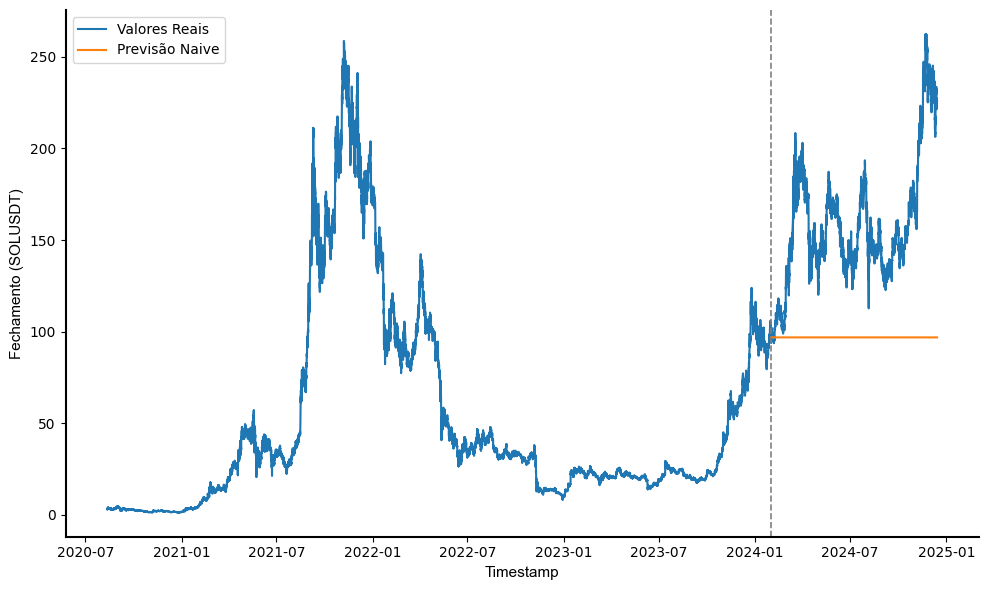

Gráfico salvo como: graficos\sol_30min_RF_forecast.jpg


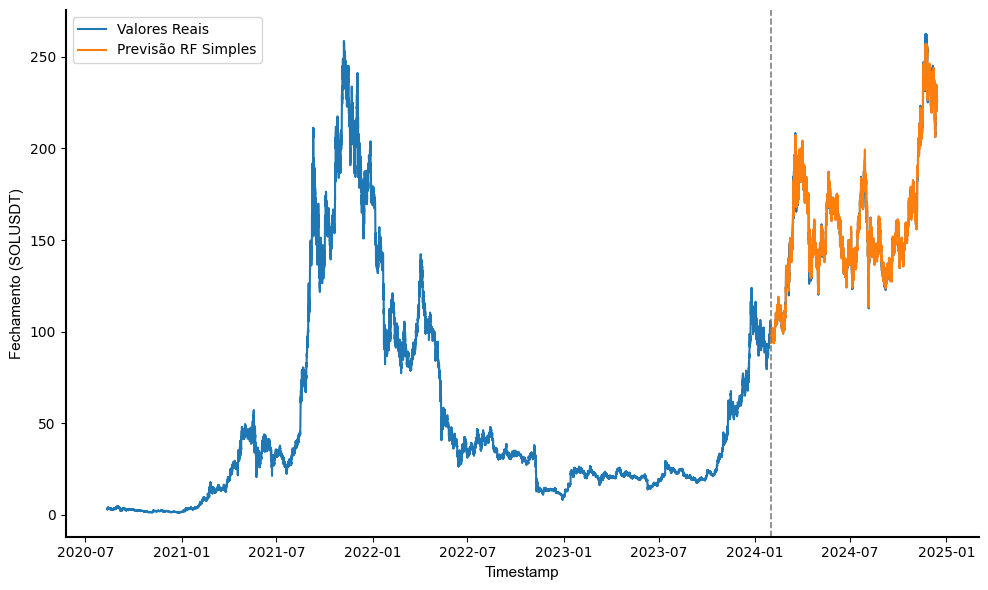

Gráfico salvo como: graficos\sol_30min_best_RF_forecast.jpg


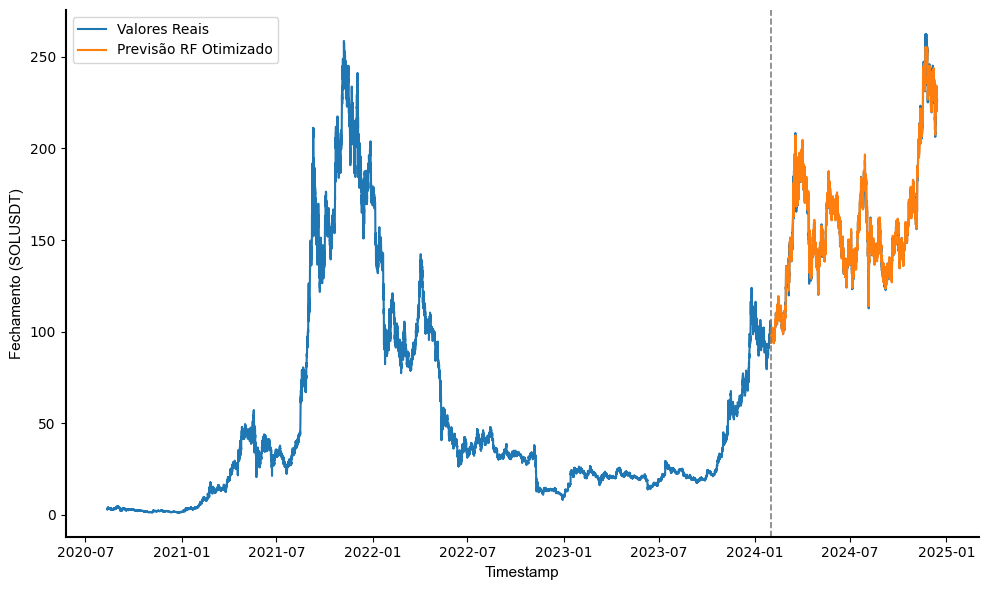

In [ ]:
# %% In[21]: Visualizando os resultados do modelo:

# 1. Vizualizar resultados de Naive

# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_test])
y_pred = pd.concat([
    # pd.Series(y_train),
    pd.Series(test["predicted_naive"], index=test.index)
])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão Naive": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_Naive_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    cores = ["blue", "orange"],
    legenda = True,
    vertical = True
)

# 2. Vizualizar resultados de RF

# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_test])
y_pred = pd.concat([
    # pd.Series(y_train),
    pd.Series(y_test_pred_RF, index=y_test.index)
])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão RF Simples": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_RF_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    cores = ["blue", "orange"],
    legenda = True,
    vertical = True
)

# 3. Vizualizar resultados de best RF
 
# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_test])
y_pred = pd.concat([
    # pd.Series(y_train),
    pd.Series(y_test_pred_best_RF, index=y_test.index)
])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão RF Otimizado": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_best_RF_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    cores = ["blue", "orange"],
    legenda = True,
    vertical = True
)

In [ ]:
# %% In[22]: Salvando os resultados obtidos:

os.makedirs("Resultados_Naive_RF", exist_ok=True)
caminho_results = os.path.join("Resultados_Naive_RF", f"Naive_RF-{df.attrs['source']}.csv")

arquivo = pd.DataFrame(results)
arquivo.to_csv(caminho_results, index = False)

caminho_param = os.path.join("Resultados_Naive_RF", f"Best_param-{df.attrs['source']}.csv")
best_hiperpar = pd.DataFrame(best_RF_dict)
best_hiperpar.to_csv(caminho_param, index = False)

# %% [markdown]

 -*- coding: utf-8 -*-  <br>
 MBA Data Science e Analytics USP/ESALQ <br>
 Código para o desenvolvimento do TCC - Parte 02 <br>
 Autor: Ronaldo do Couto Silva Filho

# %% [markdown]


 ### 4. Aplicação de Técnicas de Machine Learning
 Aplicar técnicas de Machine Learning para Analisar dados e fazer previsões,
 validações e testes serão realizados na sequencia sem a devida separação em
 tópicos

In [ ]:
#%% In[0]: Importação de Pacotes

import os
import random
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from time import time
from utils import formatar_grafico_mbausp, read_parquet_with_source
from pprint import pprint

In [ ]:
# %% In[1]: Definir a seed para reprodutibilidade

seed = 0
np.random.seed(seed)
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

# %% [markdown]


 A partir desse ponto todo o código será desenvolvido para apenas uma cripto e
 um tamanho de base (resample), a alteração da base de dados em parquet se faz
 necessária para treinar os modelos nos respectivos casos.

In [ ]:
# %% In[2]: Carregar a Base de Dados

# Nesse momento carrega-se a base de dados a ser analisada

# # 30 min
# df = read_parquet_with_source("databases_parquet/sol_30min")
df = read_parquet_with_source("databases_parquet/eth_30min")

# # 1 hora
# df = read_parquet_with_source("databases_parquet/sol_1hr")
# df = read_parquet_with_source("databases_parquet/eth_1hr")

# # 1 dia
# df = read_parquet_with_source("databases_parquet/sol_1dia")
# df = read_parquet_with_source("databases_parquet/eth_1dia")

In [ ]:
# %% In[15]: Segregar o dataset em dados de treino e teste

def segrega_data_set(df, target='close', prop_treino=0.8):
    # Proporções
    train_size = int(len(df) * prop_treino)  

    # Divisão em treino e teste
    train = df[:train_size]
    test = df[train_size:]

    # Verificando as divisões
    print(f'Tamanho treino: {len(train)}, teste: {len(test)}')

    # Separa os atributos (X) e o alvo (y)
    X_train, y_train = train.drop(columns=[target]), train[target]
    X_test, y_test = test.drop(columns=[target]), test[target]

    return X_train, y_train, X_test, y_test, test

X_train, y_train, X_test, y_test, test = segrega_data_set(df)

Tamanho treino: 102688, teste: 25672


In [ ]:
# %% In[16]: Aplicar a normalização dos dados de treino do modelo

def normaliza_treino(X_train, X_test):

    # Escalonar apenas o conjunto de treino
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # Usar o mesmo escalador nos outros conjuntos
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled

X_train_scaled, X_test_scaled = normaliza_treino(X_train, X_test)

# ------------------------------------------------------------------------------------------------ #

In [ ]:
# %% In[17]: Aplicar o Algoritmoo Naive, considerando para esse algoritmo

# o ultimo valor presente no conjunto de validação

# Criando dicionário para salvar os resultados:
results = {}

def modela_Naive(df):
    # Tempo inicial
    start_time = time()

    # Criando a coluna de valores previstos
    test['predicted_naive']=test['close'][0]

    # Copiando o primeiro valor real do conjunto de teste para valores previstos
    test['predicted_naive'][0]=test['close'][0]

    # Calcular o erro (exemplo: MAE)
    mae = mean_absolute_error(test['close'].iloc[1:], 
                              test['predicted_naive'].iloc[1:])

    mse = mean_squared_error(test['close'].iloc[1:], 
                                            test['predicted_naive'].iloc[1:])

    rmse = np.sqrt(mse)

    # Calculo de Tempo de Execução
    end_time = time()
    execution_time = end_time - start_time

    metricas_benchmark = [mae, mse, rmse, 'NA', execution_time]

    # Nome dinâmico da variável, ex: "sol_1dia_Naive"
    var_name = f"{df.attrs['source']}_Naive"

    # Cria um campo no dicionário results com nome de acordo com o df em estudo
    results[var_name] = metricas_benchmark

    print(f'MAE_test do Benchmark: {mae: .2f}')
    print(f'MSE_test do Benchmark: {mse: .2f}')
    print(f'RMSE_test do Benchmark: {rmse: .2f}')
    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    # opcional: também retornar
    return metricas_benchmark

metricas_benchmark = modela_Naive(df)

MAE_test do Benchmark:  821.30
MSE_test do Benchmark:  1067552.05
RMSE_test do Benchmark:  1033.22
O tempo que o modelo levou para treinar foi de: 0.002984285354614258


<ipython-input-39-491578c6e6f1>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test['predicted_naive']=test['close'][0]
<ipython-input-39-491578c6e6f1>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['predicted_naive']=test['close'][0]
<ipython-input-39-491578c6e6f1>:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test['predicted_naive'][0]=test['close'][0]
<ipython

# %% [markdown]

 ### Modelagem
 A partir desse momento serão apresentados os algoritmos a serem utilizados
 nesse estudo. <br>

 #### 1. Random Forest

In [ ]:
# %% In[18]: Aplicar o Algoritmo de Random Forest: 1º Regularização

def RF_simple_funcion(X_train_scaled = X_train_scaled, y_train = y_train, 
              X_test_scaled = X_test_scaled, y_test = y_test, 
              mae_bench = metricas_benchmark[0]):
    """
    Hiperparâmetros utilizados para o Modelo de RF utilizado:
    Parametros = n_estimators=300, random_state=42, criterion='squared_error',
                 n_jobs=-1)
    
    rf_model = RandomForestRegressor(n_estimators=300, 
                                    random_state=42,
                                    criterion='squared_error',
                                    n_jobs=-1)
    """
    
    # Inicia a contagem de tempo para rodar o modelo:
    start_time = time()

    # Modelo Random Forest
    rf_model = RandomForestRegressor(n_estimators=300, 
                                    random_state=42,
                                    criterion='squared_error',
                                    n_jobs=-1)

    # Treinamento
    rf_model.fit(X_train_scaled, y_train)

    # Finaliza o Tempo de Execução
    end_time = time()
    execution_time = end_time - start_time

    # — Avaliação do modelo no conjunto de TREINO —
    y_train_pred = rf_model.predict(X_train_scaled)

    mae_rf_train = mean_absolute_error(y_train, y_train_pred)
    mse_rf_train = mean_squared_error(y_train, y_train_pred)
    rmse_rf_train= np.sqrt(mae_rf_train)
    mase_rf_train= mean_absolute_error(y_train, y_train_pred)/mae_bench
    execution_time = end_time - start_time

    results_RF_train = [mae_rf_train, mse_rf_train,
                        rmse_rf_train, mase_rf_train, execution_time]

    print(
        "Resultados das métricas para o modelo de RF com dados de treino são: ")
    pprint(results_RF_train)
    print()

    # Nome dinâmico da variável, ex: "sol_1dia_RF_train"
    var_name = f"{df.attrs['source']}_RF_train"

    # Cria um campo no dicionário results com nome de acordo com o df em estudo
    results[var_name] = results_RF_train

    # Previsão no conjunto de teste
    y_test_pred = rf_model.predict(X_test_scaled)

    # Avaliação no conjunto de teste
    mae_rf_test = mean_absolute_error(y_test, y_test_pred)
    mse_rf_test = mean_squared_error(y_test, y_test_pred)
    rmse_rf_test = np.sqrt(mse_rf_test)

    # Calculo do incicador MASE
    mase_rf_test = mae_rf_test/mae_bench

    results_RF_test = [mae_rf_test, mse_rf_test, rmse_rf_test, mase_rf_test,
                    execution_time]

    print("Resultados das métricas para o modelo de RF com dados de teste são: ")
    pprint(results_RF_test)

    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    # Salvando o resultado das métricas na respectiva variável
    var_name = f"{df.attrs['source']}_RF_teste"
    results[var_name] = results_RF_test

    return y_test_pred

y_test_pred_RF = RF_simple_funcion()

Resultados das métricas para o modelo de RF com dados de treino são: 
[1.2483343460974352,
 7.7256948189607915,
 np.float64(1.1172888373636582),
 0.0015199492525108077,
 30.555644035339355]

Resultados das métricas para o modelo de RF com dados de teste são: 
[7.248216191256469,
 119.78159851002754,
 np.float64(10.944477991664451),
 0.008825296537244445,
 30.555644035339355]
O tempo que o modelo levou para treinar foi de: 30.555644035339355


In [ ]:
#%% In[19]: Random Forest com GridSearch

def RF_GridSearch_function(X_train_scaled = X_train_scaled, y_train = y_train):

    start_time = time()

    param_grid = {
        "n_estimators": [100, 300, 500, 1000], # [100, 200, 400, 800, 1000]
        "max_features": ["sqrt", None], # Como sqrt(4)=log2(4), não usado
        "max_depth": [10, 20, 100, None], # [5, 10, 20, 40, 80, 100]
        "min_samples_leaf":[5,10], 
        }

    rf_model = RandomForestRegressor(random_state=42)

    grid_search = GridSearchCV(estimator=rf_model, 
                            param_grid=param_grid, 
                            scoring='neg_root_mean_squared_error', 
                            cv=4, 
                            n_jobs=-1)

    grid_search.fit(X_train_scaled, y_train.values)

    end_time = time()
    execution_time = end_time - start_time

    # Print the best parameters and the best score
    print(grid_search)
    print(grid_search.best_params_)
    print(grid_search.best_score_)

    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    print(grid_search.best_params_['max_depth'],
        grid_search.best_params_['max_features'], 
        grid_search.best_params_['min_samples_leaf'], 
        grid_search.best_params_['n_estimators'])
    
    return grid_search

grid_search = RF_GridSearch_function()

# Salvando em um dicionário os melhores parâmetros
best_RF_dict = {}
var_name = f"{df.attrs['source']}_best_RF_params"
best_RF_dict[var_name] = grid_search.best_params_

GridSearchCV(cv=4, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 100, None],
                         'max_features': ['sqrt', None],
                         'min_samples_leaf': [5, 10],
                         'n_estimators': [100, 300, 500, 1000]},
             scoring='neg_root_mean_squared_error')
{'max_depth': 100, 'max_features': None, 'min_samples_leaf': 5, 'n_estimators': 1000}
-78.73942615293501
O tempo que o modelo levou para treinar foi de: 3048.2640035152435
100 None 5 1000


In [ ]:
#%% In[20]: Rodando o melhor modelo (best_RF)

def best_RF_function(X_train_scaled=X_train_scaled,y_train=y_train,
            mae_bench=metricas_benchmark[0],
            grid_search=grid_search):

    start_time = time()

    best_rf_model = RandomForestRegressor(
                n_estimators = grid_search.best_params_['n_estimators'],
                max_features = grid_search.best_params_['max_features'],
                max_depth = grid_search.best_params_['max_depth'],
                min_samples_leaf = grid_search.best_params_['min_samples_leaf'],
                random_state = 42,
                n_jobs = -1)

    best_rf_model.fit(X_train_scaled, y_train.values)

    end_time = time()
    execution_time = end_time - start_time
    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    # Previsão no conjunto de treino
    y_train_pred = best_rf_model.predict(X_train_scaled)

    # Avaliação no conjunto de teste
    mae_rf_train = mean_absolute_error(y_train, y_train_pred)
    mse_rf_train = mean_squared_error(y_train, y_train_pred)
    rmse_rf_train = np.sqrt(mse_rf_train)
    mase_rf_train = mae_rf_train/mae_bench

    # Salvando valores de treino
    results_best_RF_train = [mae_rf_train, mse_rf_train, rmse_rf_train,
                         mase_rf_train, execution_time]

    var_name = f"{df.attrs['source']}_best_RF_train"
    results[var_name] = results_best_RF_train
    
    print("Resultados das métricas para o melhor modelo de RF com dados " \
        "de treino são: ")
    pprint(results_best_RF_train)
    print()
    

    # Previsão no conjunto de teste
    y_test_pred = best_rf_model.predict(X_test_scaled)

    # Avaliação no conjunto de teste
    mae_rf_test = mean_absolute_error(y_test, y_test_pred)
    mse_rf_test = mean_squared_error(y_test, y_test_pred)
    rmse_rf_test = np.sqrt(mse_rf_test)
    mase_rf_test = mae_rf_test/mae_bench

    # Salvando valores de treino
    results_best_RF_test = [mae_rf_test, mse_rf_test, rmse_rf_test,
                         mase_rf_test, execution_time]
    
    var_name = f"{df.attrs['source']}_best_RF_test"
    results[var_name] = results_best_RF_test
    
    print("Resultados das métricas para o melhor modelo de RF com dados " \
        "de teste são: ")
    pprint(results_best_RF_test)
    print()

    return y_test_pred, y_train_pred

y_test_pred_best_RF,  y_train_pred_best_RF= best_RF_function()

O tempo que o modelo levou para treinar foi de: 55.307915687561035
Resultados das métricas para o melhor modelo de RF com dados de treino são: 
[2.4713315736617356,
 34.04687494473889,
 np.float64(5.834970003756565),
 0.0030090484891619937,
 55.307915687561035]

Resultados das métricas para o melhor modelo de RF com dados de teste são: 
[7.502627242656452,
 129.69392788474107,
 np.float64(11.388324191238194),
 0.009135062817900564,
 55.307915687561035]



# %% [markdown]

 # 6. Interpretação dos Resultados:

Gráfico salvo como: graficos\eth_30min_Naive_forecast.jpg


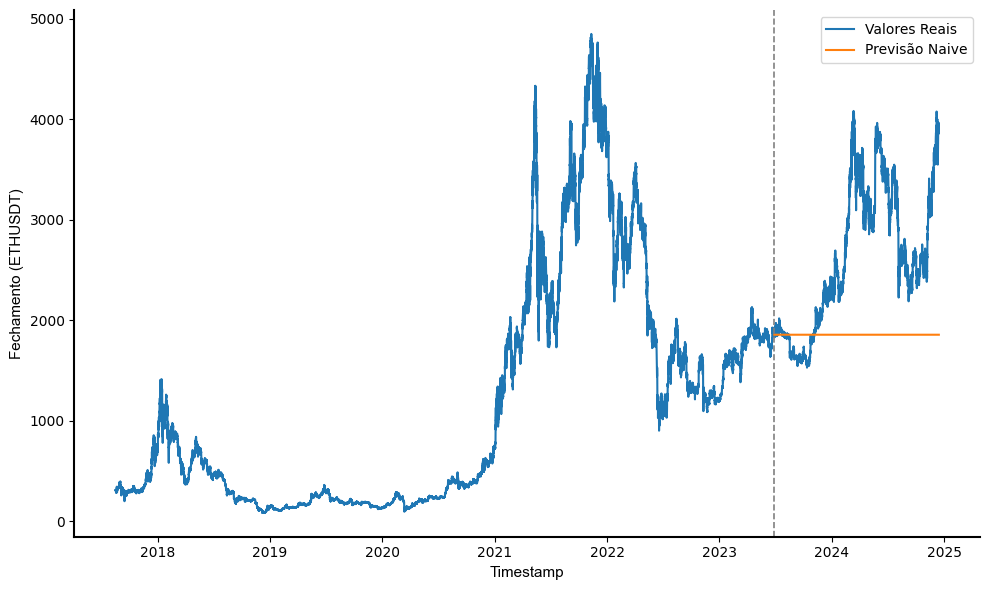

Gráfico salvo como: graficos\eth_30min_RF_forecast.jpg


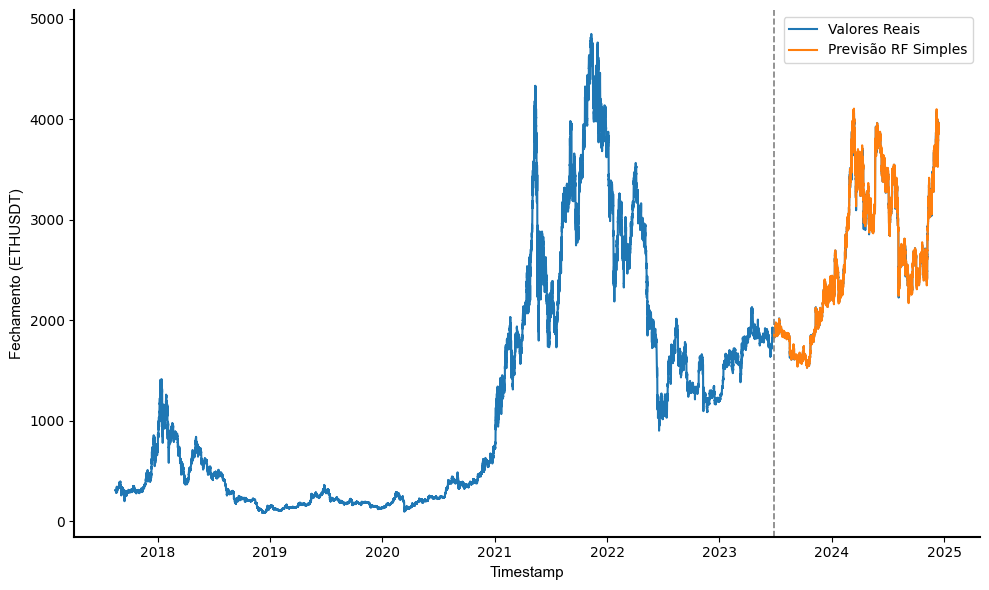

Gráfico salvo como: graficos\eth_30min_best_RF_forecast.jpg


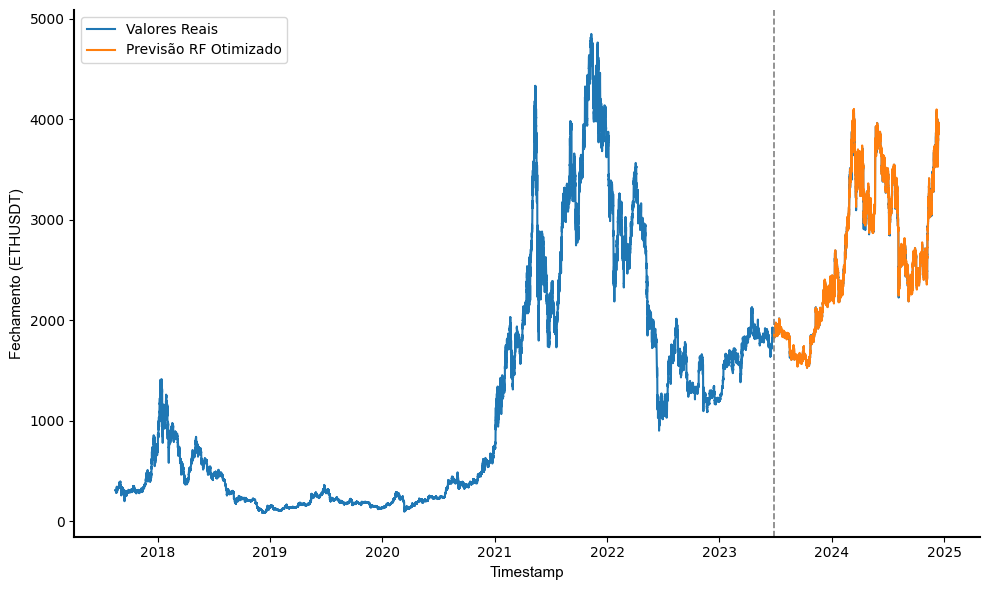

In [ ]:
# %% In[21]: Visualizando os resultados do modelo:

# 1. Vizualizar resultados de Naive

# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_test])
y_pred = pd.concat([
    # pd.Series(y_train),
    pd.Series(test["predicted_naive"], index=test.index)
])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão Naive": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_Naive_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    cores = ["blue", "orange"],
    legenda = True,
    vertical = True
)

# 2. Vizualizar resultados de RF

# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_test])
y_pred = pd.concat([
    # pd.Series(y_train),
    pd.Series(y_test_pred_RF, index=y_test.index)
])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão RF Simples": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_RF_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    cores = ["blue", "orange"],
    legenda = True,
    vertical = True
)

# 3. Vizualizar resultados de best RF
 
# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_test])
y_pred = pd.concat([
    # pd.Series(y_train),
    pd.Series(y_test_pred_best_RF, index=y_test.index)
])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão RF Otimizado": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_best_RF_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    cores = ["blue", "orange"],
    legenda = True,
    vertical = True
)

In [ ]:
# %% In[22]: Salvando os resultados obtidos:

os.makedirs("Resultados_Naive_RF", exist_ok=True)
caminho_results = os.path.join("Resultados_Naive_RF", f"Naive_RF-{df.attrs['source']}.csv")

arquivo = pd.DataFrame(results)
arquivo.to_csv(caminho_results, index = False)

caminho_param = os.path.join("Resultados_Naive_RF", f"Best_param-{df.attrs['source']}.csv")
best_hiperpar = pd.DataFrame(best_RF_dict)
best_hiperpar.to_csv(caminho_param, index = False)

# %% [markdown]

 -*- coding: utf-8 -*-  <br>
 MBA Data Science e Analytics USP/ESALQ <br>
 Código para o desenvolvimento do TCC - Parte 02 <br>
 Autor: Ronaldo do Couto Silva Filho

# %% [markdown]


 ### 4. Aplicação de Técnicas de Machine Learning
 Aplicar técnicas de Machine Learning para Analisar dados e fazer previsões,
 validações e testes serão realizados na sequencia sem a devida separação em
 tópicos

In [ ]:
#%% In[0]: Importação de Pacotes

import os
import random
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from time import time
from utils import formatar_grafico_mbausp, read_parquet_with_source
from pprint import pprint

In [ ]:
# %% In[1]: Definir a seed para reprodutibilidade

seed = 0
np.random.seed(seed)
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

# %% [markdown]


 A partir desse ponto todo o código será desenvolvido para apenas uma cripto e
 um tamanho de base (resample), a alteração da base de dados em parquet se faz
 necessária para treinar os modelos nos respectivos casos.

In [ ]:
# %% In[2]: Carregar a Base de Dados

# Nesse momento carrega-se a base de dados a ser analisada

# # 30 min
# df = read_parquet_with_source("databases_parquet/sol_30min")
# df = read_parquet_with_source("databases_parquet/eth_30min")

# # 1 hora
# df = read_parquet_with_source("databases_parquet/sol_1hr")
# df = read_parquet_with_source("databases_parquet/eth_1hr")

# # 1 dia
# df = read_parquet_with_source("databases_parquet/sol_1dia")
df = read_parquet_with_source("databases_parquet/eth_1dia")

In [ ]:
# %% In[15]: Segregar o dataset em dados de treino e teste

def segrega_data_set(df, target='close', prop_treino=0.8):
    # Proporções
    train_size = int(len(df) * prop_treino)  

    # Divisão em treino e teste
    train = df[:train_size]
    test = df[train_size:]

    # Verificando as divisões
    print(f'Tamanho treino: {len(train)}, teste: {len(test)}')

    # Separa os atributos (X) e o alvo (y)
    X_train, y_train = train.drop(columns=[target]), train[target]
    X_test, y_test = test.drop(columns=[target]), test[target]

    return X_train, y_train, X_test, y_test, test

X_train, y_train, X_test, y_test, test = segrega_data_set(df)

Tamanho treino: 2131, teste: 533


In [ ]:
# %% In[16]: Aplicar a normalização dos dados de treino do modelo

def normaliza_treino(X_train, X_test):

    # Escalonar apenas o conjunto de treino
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # Usar o mesmo escalador nos outros conjuntos
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled

X_train_scaled, X_test_scaled = normaliza_treino(X_train, X_test)

# ------------------------------------------------------------------------------------------------ #

In [ ]:
# %% In[17]: Aplicar o Algoritmoo Naive, considerando para esse algoritmo

# o ultimo valor presente no conjunto de validação

# Criando dicionário para salvar os resultados:
results = {}

def modela_Naive(df):
    # Tempo inicial
    start_time = time()

    # Criando a coluna de valores previstos
    test['predicted_naive']=test['close'][0]

    # Copiando o primeiro valor real do conjunto de teste para valores previstos
    test['predicted_naive'][0]=test['close'][0]

    # Calcular o erro (exemplo: MAE)
    mae = mean_absolute_error(test['close'].iloc[1:], 
                              test['predicted_naive'].iloc[1:])

    mse = mean_squared_error(test['close'].iloc[1:], 
                                            test['predicted_naive'].iloc[1:])

    rmse = np.sqrt(mse)

    # Calculo de Tempo de Execução
    end_time = time()
    execution_time = end_time - start_time

    metricas_benchmark = [mae, mse, rmse, 'NA', execution_time]

    # Nome dinâmico da variável, ex: "sol_1dia_Naive"
    var_name = f"{df.attrs['source']}_Naive"

    # Cria um campo no dicionário results com nome de acordo com o df em estudo
    results[var_name] = metricas_benchmark

    print(f'MAE_test do Benchmark: {mae: .2f}')
    print(f'MSE_test do Benchmark: {mse: .2f}')
    print(f'RMSE_test do Benchmark: {rmse: .2f}')
    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    # opcional: também retornar
    return metricas_benchmark

metricas_benchmark = modela_Naive(df)

MAE_test do Benchmark:  789.74
MSE_test do Benchmark:  979796.22
RMSE_test do Benchmark:  989.85
O tempo que o modelo levou para treinar foi de: 0.003994941711425781


<ipython-input-50-491578c6e6f1>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test['predicted_naive']=test['close'][0]
<ipython-input-50-491578c6e6f1>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['predicted_naive']=test['close'][0]
<ipython-input-50-491578c6e6f1>:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test['predicted_naive'][0]=test['close'][0]
<ipython

# %% [markdown]

 ### Modelagem
 A partir desse momento serão apresentados os algoritmos a serem utilizados
 nesse estudo. <br>

 #### 1. Random Forest

In [ ]:
# %% In[18]: Aplicar o Algoritmo de Random Forest: 1º Regularização

def RF_simple_funcion(X_train_scaled = X_train_scaled, y_train = y_train, 
              X_test_scaled = X_test_scaled, y_test = y_test, 
              mae_bench = metricas_benchmark[0]):
    """
    Hiperparâmetros utilizados para o Modelo de RF utilizado:
    Parametros = n_estimators=300, random_state=42, criterion='squared_error',
                 n_jobs=-1)
    
    rf_model = RandomForestRegressor(n_estimators=300, 
                                    random_state=42,
                                    criterion='squared_error',
                                    n_jobs=-1)
    """
    
    # Inicia a contagem de tempo para rodar o modelo:
    start_time = time()

    # Modelo Random Forest
    rf_model = RandomForestRegressor(n_estimators=300, 
                                    random_state=42,
                                    criterion='squared_error',
                                    n_jobs=-1)

    # Treinamento
    rf_model.fit(X_train_scaled, y_train)

    # Finaliza o Tempo de Execução
    end_time = time()
    execution_time = end_time - start_time

    # — Avaliação do modelo no conjunto de TREINO —
    y_train_pred = rf_model.predict(X_train_scaled)

    mae_rf_train = mean_absolute_error(y_train, y_train_pred)
    mse_rf_train = mean_squared_error(y_train, y_train_pred)
    rmse_rf_train= np.sqrt(mae_rf_train)
    mase_rf_train= mean_absolute_error(y_train, y_train_pred)/mae_bench
    execution_time = end_time - start_time

    results_RF_train = [mae_rf_train, mse_rf_train,
                        rmse_rf_train, mase_rf_train, execution_time]

    print(
        "Resultados das métricas para o modelo de RF com dados de treino são: ")
    pprint(results_RF_train)
    print()

    # Nome dinâmico da variável, ex: "sol_1dia_RF_train"
    var_name = f"{df.attrs['source']}_RF_train"

    # Cria um campo no dicionário results com nome de acordo com o df em estudo
    results[var_name] = results_RF_train

    # Previsão no conjunto de teste
    y_test_pred = rf_model.predict(X_test_scaled)

    # Avaliação no conjunto de teste
    mae_rf_test = mean_absolute_error(y_test, y_test_pred)
    mse_rf_test = mean_squared_error(y_test, y_test_pred)
    rmse_rf_test = np.sqrt(mse_rf_test)

    # Calculo do incicador MASE
    mase_rf_test = mae_rf_test/mae_bench

    results_RF_test = [mae_rf_test, mse_rf_test, rmse_rf_test, mase_rf_test,
                    execution_time]

    print("Resultados das métricas para o modelo de RF com dados de teste são: ")
    pprint(results_RF_test)

    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    # Salvando o resultado das métricas na respectiva variável
    var_name = f"{df.attrs['source']}_RF_teste"
    results[var_name] = results_RF_test

    return y_test_pred

y_test_pred_RF = RF_simple_funcion()

Resultados das métricas para o modelo de RF com dados de treino são: 
[10.440975967871626,
 388.651514074282,
 np.float64(3.231249907987871),
 0.013220752933851844,
 0.3975698947906494]

Resultados das métricas para o modelo de RF com dados de teste são: 
[63.24507903269505,
 6917.583098238604,
 np.float64(83.17200910305465),
 0.08008327638586088,
 0.3975698947906494]
O tempo que o modelo levou para treinar foi de: 0.3975698947906494


In [ ]:
#%% In[19]: Random Forest com GridSearch

def RF_GridSearch_function(X_train_scaled = X_train_scaled, y_train = y_train):

    start_time = time()

    param_grid = {
        "n_estimators": [100, 300, 500, 1000], # [100, 200, 400, 800, 1000]
        "max_features": ["sqrt", None], # Como sqrt(4)=log2(4), não usado
        "max_depth": [10, 20, 100, None], # [5, 10, 20, 40, 80, 100]
        "min_samples_leaf":[5,10], 
        }

    rf_model = RandomForestRegressor(random_state=42)

    grid_search = GridSearchCV(estimator=rf_model, 
                            param_grid=param_grid, 
                            scoring='neg_root_mean_squared_error', 
                            cv=4, 
                            n_jobs=-1)

    grid_search.fit(X_train_scaled, y_train.values)

    end_time = time()
    execution_time = end_time - start_time

    # Print the best parameters and the best score
    print(grid_search)
    print(grid_search.best_params_)
    print(grid_search.best_score_)

    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    print(grid_search.best_params_['max_depth'],
        grid_search.best_params_['max_features'], 
        grid_search.best_params_['min_samples_leaf'], 
        grid_search.best_params_['n_estimators'])
    
    return grid_search, execution_time

grid_search, time_GS = RF_GridSearch_function()

# Salvando em um dicionário os melhores parâmetros
best_RF_dict = {}
var_name = f"{df.attrs['source']}_best_RF_params"
best_RF_dict[var_name] = grid_search.best_params_

# Adicionando o tempo de execução aos dicionários criados com os melhores 
# parametros encontrados no GridSearchCV
best_RF_dict[var_name]["time"] = time_GS 

GridSearchCV(cv=4, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 100, None],
                         'max_features': ['sqrt', None],
                         'min_samples_leaf': [5, 10],
                         'n_estimators': [100, 300, 500, 1000]},
             scoring='neg_root_mean_squared_error')
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 300}
-152.20917549403532
O tempo que o modelo levou para treinar foi de: 43.056583404541016
10 sqrt 5 300


In [ ]:
#%% In[20]: Rodando o melhor modelo (best_RF)

def best_RF_function(X_train_scaled=X_train_scaled,y_train=y_train,
            mae_bench=metricas_benchmark[0],
            grid_search=grid_search):

    start_time = time()

    best_rf_model = RandomForestRegressor(
                n_estimators = grid_search.best_params_['n_estimators'],
                max_features = grid_search.best_params_['max_features'],
                max_depth = grid_search.best_params_['max_depth'],
                min_samples_leaf = grid_search.best_params_['min_samples_leaf'],
                random_state = 42,
                n_jobs = -1)

    best_rf_model.fit(X_train_scaled, y_train.values)

    end_time = time()
    execution_time = end_time - start_time
    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    # Previsão no conjunto de treino
    y_train_pred = best_rf_model.predict(X_train_scaled)

    # Avaliação no conjunto de teste
    mae_rf_train = mean_absolute_error(y_train, y_train_pred)
    mse_rf_train = mean_squared_error(y_train, y_train_pred)
    rmse_rf_train = np.sqrt(mse_rf_train)
    mase_rf_train = mae_rf_train/mae_bench

    # Salvando valores de treino
    results_best_RF_train = [mae_rf_train, mse_rf_train, rmse_rf_train,
                         mase_rf_train, execution_time]

    var_name = f"{df.attrs['source']}_best_RF_train"
    results[var_name] = results_best_RF_train
    
    print("Resultados das métricas para o melhor modelo de RF com dados " \
        "de treino são: ")
    pprint(results_best_RF_train)
    print()
    

    # Previsão no conjunto de teste
    y_test_pred = best_rf_model.predict(X_test_scaled)

    # Avaliação no conjunto de teste
    mae_rf_test = mean_absolute_error(y_test, y_test_pred)
    mse_rf_test = mean_squared_error(y_test, y_test_pred)
    rmse_rf_test = np.sqrt(mse_rf_test)
    mase_rf_test = mae_rf_test/mae_bench

    # Salvando valores de treino
    results_best_RF_test = [mae_rf_test, mse_rf_test, rmse_rf_test,
                         mase_rf_test, execution_time]
    
    var_name = f"{df.attrs['source']}_best_RF_test"
    results[var_name] = results_best_RF_test
    
    print("Resultados das métricas para o melhor modelo de RF com dados " \
        "de teste são: ")
    pprint(results_best_RF_test)
    print()

    return y_test_pred, y_train_pred

y_test_pred_best_RF,  y_train_pred_best_RF= best_RF_function()

O tempo que o modelo levou para treinar foi de: 0.2896242141723633
Resultados das métricas para o melhor modelo de RF com dados de treino são: 
[24.81336906563773,
 2243.141469322341,
 np.float64(47.361814463999806),
 0.03141961277209522,
 0.2896242141723633]

Resultados das métricas para o melhor modelo de RF com dados de teste são: 
[64.59317619796833,
 7060.800573546442,
 np.float64(84.02856998394321),
 0.08179028726374697,
 0.2896242141723633]



# %% [markdown]

 # 6. Interpretação dos Resultados:

Gráfico salvo como: graficos\eth_1dia_Naive_forecast.jpg


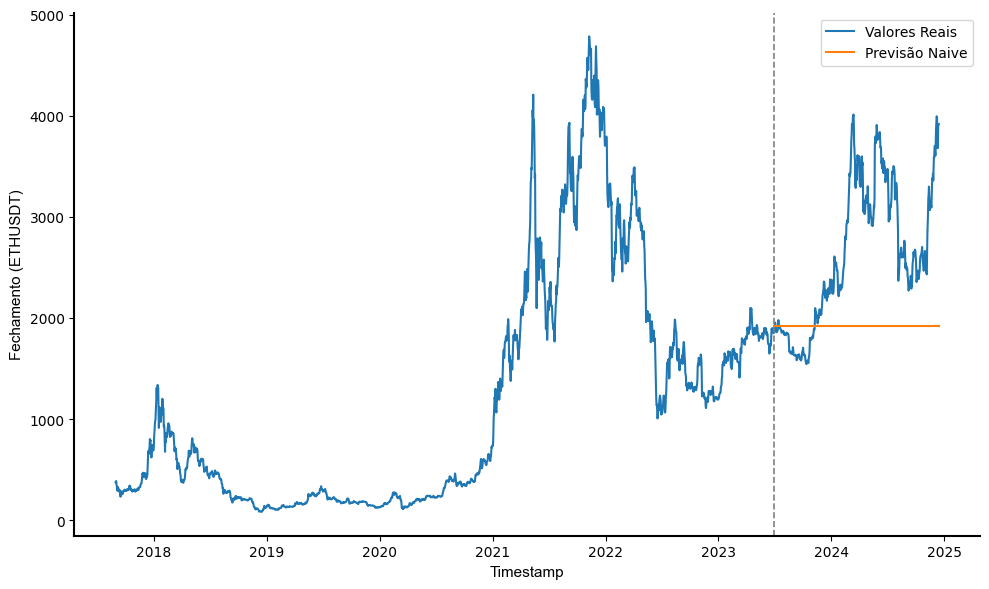

Gráfico salvo como: graficos\eth_1dia_RF_forecast.jpg


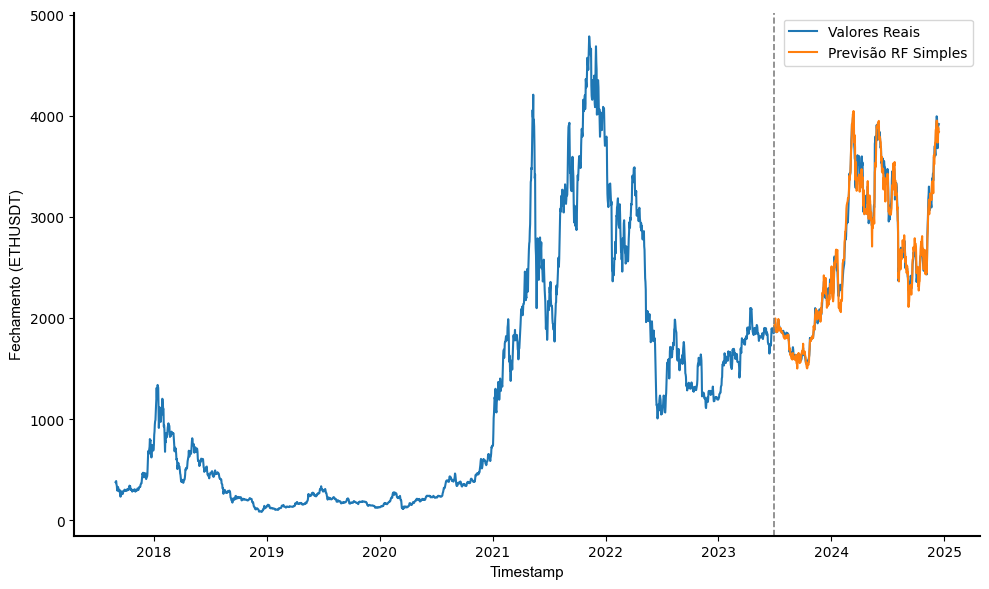

Gráfico salvo como: graficos\eth_1dia_best_RF_forecast.jpg


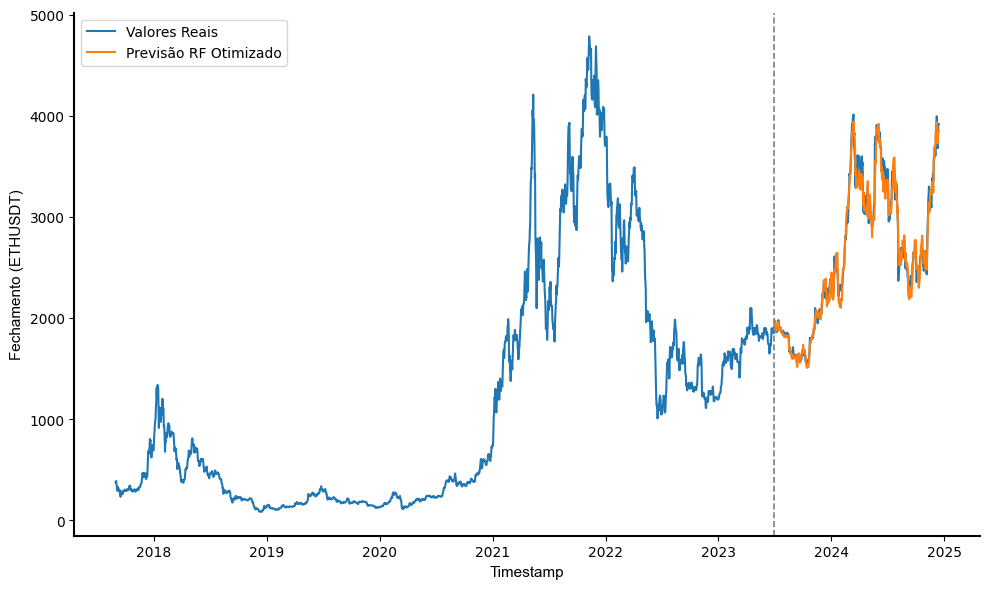

In [ ]:
# %% In[21]: Visualizando os resultados do modelo:

# 1. Vizualizar resultados de Naive

# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_test])
y_pred = pd.concat([
    # pd.Series(y_train),
    pd.Series(test["predicted_naive"], index=test.index)
])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão Naive": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_Naive_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    cores = ["blue", "orange"],
    legenda = True,
    vertical = True
)

# 2. Vizualizar resultados de RF

# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_test])
y_pred = pd.concat([
    # pd.Series(y_train),
    pd.Series(y_test_pred_RF, index=y_test.index)
])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão RF Simples": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_RF_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    cores = ["blue", "orange"],
    legenda = True,
    vertical = True
)

# 3. Vizualizar resultados de best RF
 
# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_test])
y_pred = pd.concat([
    # pd.Series(y_train),
    pd.Series(y_test_pred_best_RF, index=y_test.index)
])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão RF Otimizado": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_best_RF_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    cores = ["blue", "orange"],
    legenda = True,
    vertical = True
)

In [ ]:
# %% In[22]: Salvando os resultados obtidos:

os.makedirs("Resultados_Naive_RF", exist_ok=True)
caminho_results = os.path.join("Resultados_Naive_RF", f"Naive_RF-{df.attrs['source']}.csv")

arquivo = pd.DataFrame(results)
arquivo.to_csv(caminho_results, index = False)

caminho_param = os.path.join("Resultados_Naive_RF", f"Best_param-{df.attrs['source']}.csv")
best_hiperpar = pd.DataFrame(best_RF_dict)
best_hiperpar.to_csv(caminho_param, index = False)

# %% [markdown]

 -*- coding: utf-8 -*-  <br>
 MBA Data Science e Analytics USP/ESALQ <br>
 Código para o desenvolvimento do TCC - Parte 02 <br>
 Autor: Ronaldo do Couto Silva Filho

# %% [markdown]


 ### 4. Aplicação de Técnicas de Machine Learning
 Aplicar técnicas de Machine Learning para Analisar dados e fazer previsões,
 validações e testes serão realizados na sequencia sem a devida separação em
 tópicos

In [ ]:
#%% In[0]: Importação de Pacotes

import os
import random
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from time import time
from utils import formatar_grafico_mbausp, read_parquet_with_source
from pprint import pprint

In [ ]:
# %% In[1]: Definir a seed para reprodutibilidade

seed = 0
np.random.seed(seed)
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

# %% [markdown]


 A partir desse ponto todo o código será desenvolvido para apenas uma cripto e
 um tamanho de base (resample), a alteração da base de dados em parquet se faz
 necessária para treinar os modelos nos respectivos casos.

In [ ]:
# %% In[2]: Carregar a Base de Dados

# Nesse momento carrega-se a base de dados a ser analisada

# # 30 min
# df = read_parquet_with_source("databases_parquet/sol_30min")
# df = read_parquet_with_source("databases_parquet/eth_30min")

# # 1 hora
# df = read_parquet_with_source("databases_parquet/sol_1hr")
# df = read_parquet_with_source("databases_parquet/eth_1hr")

# # 1 dia
df = read_parquet_with_source("databases_parquet/sol_1dia")
# df = read_parquet_with_source("databases_parquet/eth_1dia")

In [ ]:
# %% In[15]: Segregar o dataset em dados de treino e teste

def segrega_data_set(df, target='close', prop_treino=0.8):
    # Proporções
    train_size = int(len(df) * prop_treino)  

    # Divisão em treino e teste
    train = df[:train_size]
    test = df[train_size:]

    # Verificando as divisões
    print(f'Tamanho treino: {len(train)}, teste: {len(test)}')

    # Separa os atributos (X) e o alvo (y)
    X_train, y_train = train.drop(columns=[target]), train[target]
    X_test, y_test = test.drop(columns=[target]), test[target]

    return X_train, y_train, X_test, y_test, test

X_train, y_train, X_test, y_test, test = segrega_data_set(df)

Tamanho treino: 1259, teste: 315


In [ ]:
# %% In[16]: Aplicar a normalização dos dados de treino do modelo

def normaliza_treino(X_train, X_test):

    # Escalonar apenas o conjunto de treino
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # Usar o mesmo escalador nos outros conjuntos
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled

X_train_scaled, X_test_scaled = normaliza_treino(X_train, X_test)

# ------------------------------------------------------------------------------------------------ #

In [ ]:
# %% In[17]: Aplicar o Algoritmoo Naive, considerando para esse algoritmo

# o ultimo valor presente no conjunto de validação

# Criando dicionário para salvar os resultados:
results = {}

def modela_Naive(df):
    # Tempo inicial
    start_time = time()

    # Criando a coluna de valores previstos
    test['predicted_naive']=test['close'][0]

    # Copiando o primeiro valor real do conjunto de teste para valores previstos
    test['predicted_naive'][0]=test['close'][0]

    # Calcular o erro (exemplo: MAE)
    mae = mean_absolute_error(test['close'].iloc[1:], 
                              test['predicted_naive'].iloc[1:])

    mse = mean_squared_error(test['close'].iloc[1:], 
                                            test['predicted_naive'].iloc[1:])

    rmse = np.sqrt(mse)

    # Calculo de Tempo de Execução
    end_time = time()
    execution_time = end_time - start_time

    metricas_benchmark = [mae, mse, rmse, 'NA', execution_time]

    # Nome dinâmico da variável, ex: "sol_1dia_Naive"
    var_name = f"{df.attrs['source']}_Naive"

    # Cria um campo no dicionário results com nome de acordo com o df em estudo
    results[var_name] = metricas_benchmark

    print(f'MAE_test do Benchmark: {mae: .2f}')
    print(f'MSE_test do Benchmark: {mse: .2f}')
    print(f'RMSE_test do Benchmark: {rmse: .2f}')
    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    # opcional: também retornar
    return metricas_benchmark

metricas_benchmark = modela_Naive(df)

MAE_test do Benchmark:  62.48
MSE_test do Benchmark:  4998.64
RMSE_test do Benchmark:  70.70
O tempo que o modelo levou para treinar foi de: 0.0021719932556152344


<ipython-input-61-491578c6e6f1>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test['predicted_naive']=test['close'][0]
<ipython-input-61-491578c6e6f1>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['predicted_naive']=test['close'][0]
<ipython-input-61-491578c6e6f1>:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test['predicted_naive'][0]=test['close'][0]
<ipython

# %% [markdown]

 ### Modelagem
 A partir desse momento serão apresentados os algoritmos a serem utilizados
 nesse estudo. <br>

 #### 1. Random Forest

In [ ]:
# %% In[18]: Aplicar o Algoritmo de Random Forest: 1º Regularização

def RF_simple_funcion(X_train_scaled = X_train_scaled, y_train = y_train, 
              X_test_scaled = X_test_scaled, y_test = y_test, 
              mae_bench = metricas_benchmark[0]):
    """
    Hiperparâmetros utilizados para o Modelo de RF utilizado:
    Parametros = n_estimators=300, random_state=42, criterion='squared_error',
                 n_jobs=-1)
    
    rf_model = RandomForestRegressor(n_estimators=300, 
                                    random_state=42,
                                    criterion='squared_error',
                                    n_jobs=-1)
    """
    
    # Inicia a contagem de tempo para rodar o modelo:
    start_time = time()

    # Modelo Random Forest
    rf_model = RandomForestRegressor(n_estimators=300, 
                                    random_state=42,
                                    criterion='squared_error',
                                    n_jobs=-1)

    # Treinamento
    rf_model.fit(X_train_scaled, y_train)

    # Finaliza o Tempo de Execução
    end_time = time()
    execution_time = end_time - start_time

    # — Avaliação do modelo no conjunto de TREINO —
    y_train_pred = rf_model.predict(X_train_scaled)

    mae_rf_train = mean_absolute_error(y_train, y_train_pred)
    mse_rf_train = mean_squared_error(y_train, y_train_pred)
    rmse_rf_train= np.sqrt(mae_rf_train)
    mase_rf_train= mean_absolute_error(y_train, y_train_pred)/mae_bench
    execution_time = end_time - start_time

    results_RF_train = [mae_rf_train, mse_rf_train,
                        rmse_rf_train, mase_rf_train, execution_time]

    print(
        "Resultados das métricas para o modelo de RF com dados de treino são: ")
    pprint(results_RF_train)
    print()

    # Nome dinâmico da variável, ex: "sol_1dia_RF_train"
    var_name = f"{df.attrs['source']}_RF_train"

    # Cria um campo no dicionário results com nome de acordo com o df em estudo
    results[var_name] = results_RF_train

    # Previsão no conjunto de teste
    y_test_pred = rf_model.predict(X_test_scaled)

    # Avaliação no conjunto de teste
    mae_rf_test = mean_absolute_error(y_test, y_test_pred)
    mse_rf_test = mean_squared_error(y_test, y_test_pred)
    rmse_rf_test = np.sqrt(mse_rf_test)

    # Calculo do incicador MASE
    mase_rf_test = mae_rf_test/mae_bench

    results_RF_test = [mae_rf_test, mse_rf_test, rmse_rf_test, mase_rf_test,
                    execution_time]

    print("Resultados das métricas para o modelo de RF com dados de teste são: ")
    pprint(results_RF_test)

    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    # Salvando o resultado das métricas na respectiva variável
    var_name = f"{df.attrs['source']}_RF_teste"
    results[var_name] = results_RF_test

    return y_test_pred

y_test_pred_RF = RF_simple_funcion()

Resultados das métricas para o modelo de RF com dados de treino são: 
[0.6684693455413907,
 1.6476560467333528,
 np.float64(0.8175997465394609),
 0.010699552888378204,
 0.3004937171936035]

Resultados das métricas para o modelo de RF com dados de teste são: 
[6.956631951873392,
 74.21238824701975,
 np.float64(8.614661238088225),
 0.11134818969711795,
 0.3004937171936035]
O tempo que o modelo levou para treinar foi de: 0.3004937171936035


In [ ]:
#%% In[19]: Random Forest com GridSearch

def RF_GridSearch_function(X_train_scaled = X_train_scaled, y_train = y_train):

    start_time = time()

    param_grid = {
        "n_estimators": [100, 300, 500, 1000], # [100, 200, 400, 800, 1000]
        "max_features": ["sqrt", None], # Como sqrt(4)=log2(4), não usado
        "max_depth": [10, 20, 100, None], # [5, 10, 20, 40, 80, 100]
        "min_samples_leaf":[5,10], 
        }

    rf_model = RandomForestRegressor(random_state=42)

    grid_search = GridSearchCV(estimator=rf_model, 
                            param_grid=param_grid, 
                            scoring='neg_root_mean_squared_error', 
                            cv=4, 
                            n_jobs=-1)

    grid_search.fit(X_train_scaled, y_train.values)

    end_time = time()
    execution_time = end_time - start_time

    # Print the best parameters and the best score
    print(grid_search)
    print(grid_search.best_params_)
    print(grid_search.best_score_)

    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    print(grid_search.best_params_['max_depth'],
        grid_search.best_params_['max_features'], 
        grid_search.best_params_['min_samples_leaf'], 
        grid_search.best_params_['n_estimators'])
    
    return grid_search, execution_time

grid_search, time_GS = RF_GridSearch_function()

# Salvando em um dicionário os melhores parâmetros
best_RF_dict = {}
var_name = f"{df.attrs['source']}_best_RF_params"
best_RF_dict[var_name] = grid_search.best_params_

# Adicionando o tempo de execução aos dicionários criados com os melhores 
# parametros encontrados no GridSearchCV
best_RF_dict[var_name]["time"] = time_GS 

GridSearchCV(cv=4, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 100, None],
                         'max_features': ['sqrt', None],
                         'min_samples_leaf': [5, 10],
                         'n_estimators': [100, 300, 500, 1000]},
             scoring='neg_root_mean_squared_error')
{'max_depth': 20, 'max_features': None, 'min_samples_leaf': 5, 'n_estimators': 1000}
-17.426293608463578
O tempo que o modelo levou para treinar foi de: 28.02842926979065
20 None 5 1000


In [ ]:
#%% In[20]: Rodando o melhor modelo (best_RF)

def best_RF_function(X_train_scaled=X_train_scaled,y_train=y_train,
            mae_bench=metricas_benchmark[0],
            grid_search=grid_search):

    start_time = time()

    best_rf_model = RandomForestRegressor(
                n_estimators = grid_search.best_params_['n_estimators'],
                max_features = grid_search.best_params_['max_features'],
                max_depth = grid_search.best_params_['max_depth'],
                min_samples_leaf = grid_search.best_params_['min_samples_leaf'],
                random_state = 42,
                n_jobs = -1)

    best_rf_model.fit(X_train_scaled, y_train.values)

    end_time = time()
    execution_time = end_time - start_time
    print(f'O tempo que o modelo levou para treinar foi de: {execution_time}')

    # Previsão no conjunto de treino
    y_train_pred = best_rf_model.predict(X_train_scaled)

    # Avaliação no conjunto de teste
    mae_rf_train = mean_absolute_error(y_train, y_train_pred)
    mse_rf_train = mean_squared_error(y_train, y_train_pred)
    rmse_rf_train = np.sqrt(mse_rf_train)
    mase_rf_train = mae_rf_train/mae_bench

    # Salvando valores de treino
    results_best_RF_train = [mae_rf_train, mse_rf_train, rmse_rf_train,
                         mase_rf_train, execution_time]

    var_name = f"{df.attrs['source']}_best_RF_train"
    results[var_name] = results_best_RF_train
    
    print("Resultados das métricas para o melhor modelo de RF com dados " \
        "de treino são: ")
    pprint(results_best_RF_train)
    print()
    

    # Previsão no conjunto de teste
    y_test_pred = best_rf_model.predict(X_test_scaled)

    # Avaliação no conjunto de teste
    mae_rf_test = mean_absolute_error(y_test, y_test_pred)
    mse_rf_test = mean_squared_error(y_test, y_test_pred)
    rmse_rf_test = np.sqrt(mse_rf_test)
    mase_rf_test = mae_rf_test/mae_bench

    # Salvando valores de treino
    results_best_RF_test = [mae_rf_test, mse_rf_test, rmse_rf_test,
                         mase_rf_test, execution_time]
    
    var_name = f"{df.attrs['source']}_best_RF_test"
    results[var_name] = results_best_RF_test
    
    print("Resultados das métricas para o melhor modelo de RF com dados " \
        "de teste são: ")
    pprint(results_best_RF_test)
    print()

    return y_test_pred, y_train_pred

y_test_pred_best_RF,  y_train_pred_best_RF= best_RF_function()

O tempo que o modelo levou para treinar foi de: 0.8375484943389893
Resultados das métricas para o melhor modelo de RF com dados de treino são: 
[1.40492738668399,
 7.481769827552406,
 np.float64(2.735282403619854),
 0.022487336148498915,
 0.8375484943389893]

Resultados das métricas para o melhor modelo de RF com dados de teste são: 
[6.603145923497863,
 66.76347812687469,
 np.float64(8.170892125519385),
 0.1056902751178883,
 0.8375484943389893]



# %% [markdown]

 # 6. Interpretação dos Resultados:

Gráfico salvo como: graficos\sol_1dia_Naive_forecast.jpg


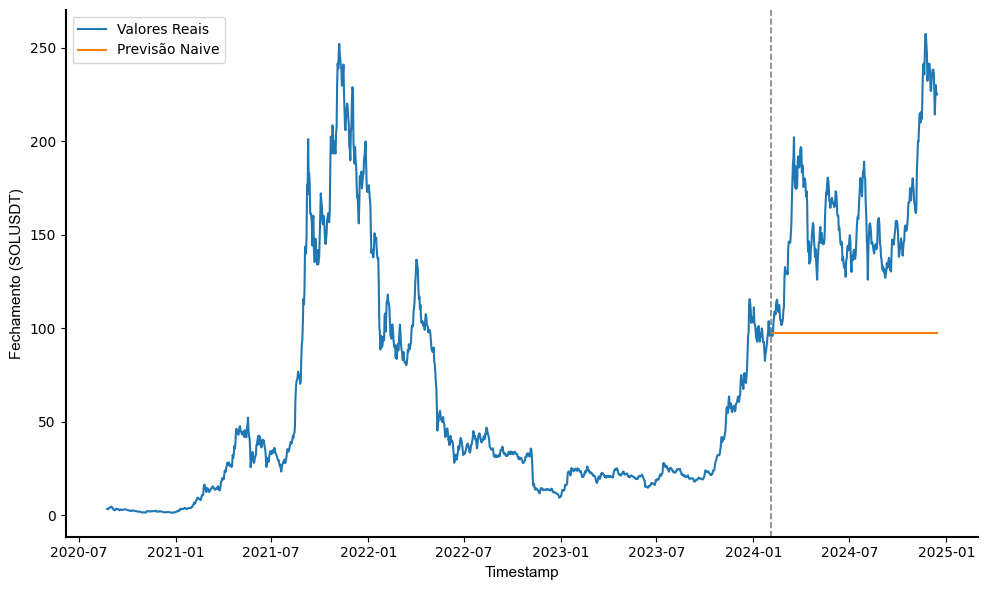

Gráfico salvo como: graficos\sol_1dia_RF_forecast.jpg


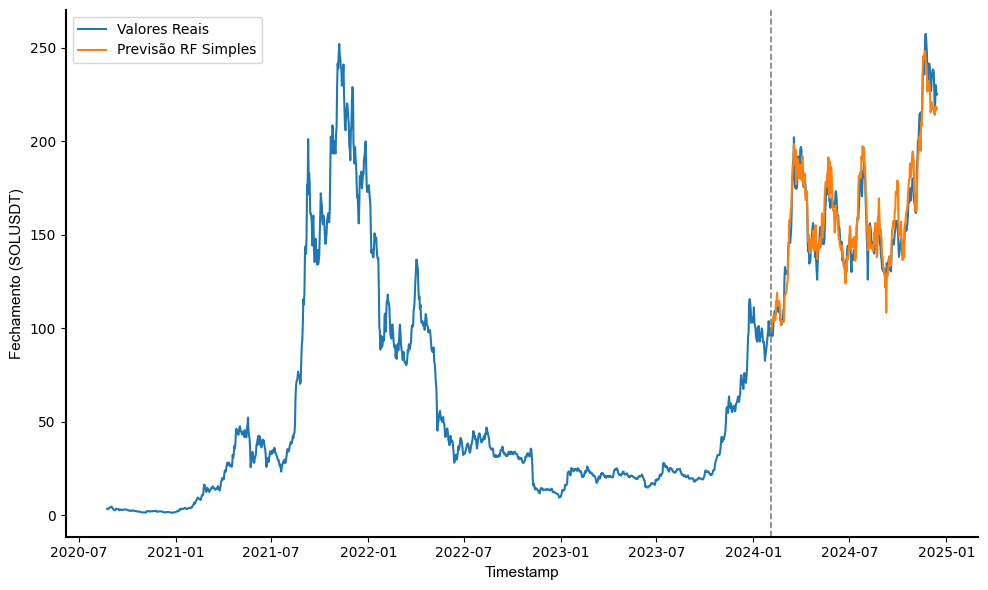

Gráfico salvo como: graficos\sol_1dia_best_RF_forecast.jpg


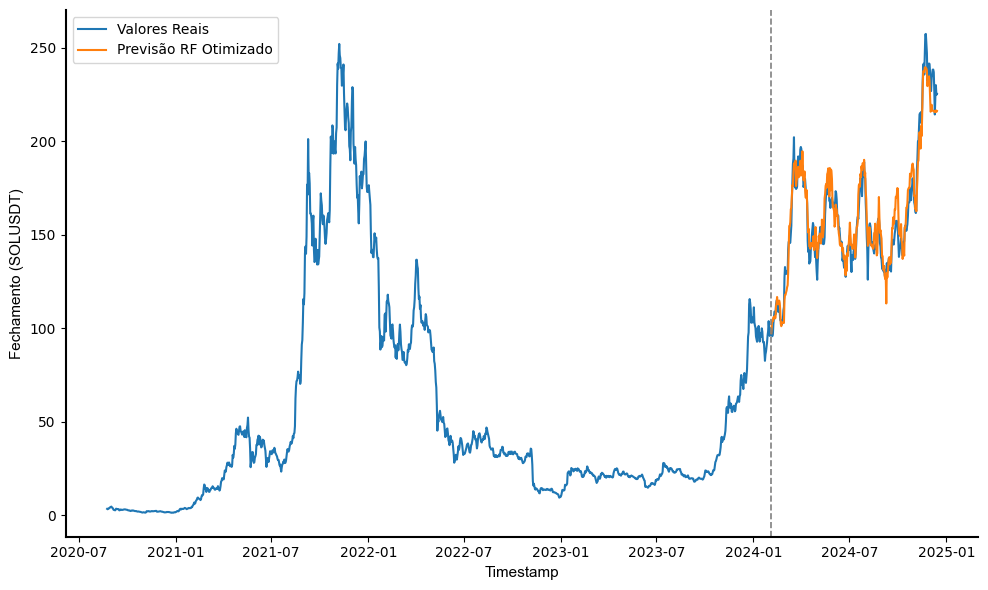

In [ ]:
# %% In[21]: Visualizando os resultados do modelo:

# 1. Vizualizar resultados de Naive

# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_test])
y_pred = pd.concat([
    # pd.Series(y_train),
    pd.Series(test["predicted_naive"], index=test.index)
])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão Naive": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_Naive_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    cores = ["blue", "orange"],
    legenda = True,
    vertical = True
)

# 2. Vizualizar resultados de RF

# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_test])
y_pred = pd.concat([
    # pd.Series(y_train),
    pd.Series(y_test_pred_RF, index=y_test.index)
])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão RF Simples": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_RF_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    cores = ["blue", "orange"],
    legenda = True,
    vertical = True
)

# 3. Vizualizar resultados de best RF
 
# Concatenando valores reais e previstos
y_real = pd.concat([y_train, y_test])
y_pred = pd.concat([
    # pd.Series(y_train),
    pd.Series(y_test_pred_best_RF, index=y_test.index)
])

# Organizando as séries para o gráfico
series_plot = {
    "Valores Reais": (y_real.index, y_real),
    "Previsão RF Otimizado": (y_pred.index, y_pred)
}

# Chamando a função com estilos e salvando automaticamente
moeda = f"{df.attrs['source']}".split("_")[0].upper()
moeda = moeda + "USDT"
eixo_y = f"Fechamento ({moeda})"

nome_arquivo = f"{df.attrs['source']}_best_RF_forecast"

formatar_grafico_mbausp(
    series = series_plot,
    # titulo="Série Temporal: Original vs Previsões (Random Forest)",
    titulo_x = "Timestamp",
    titulo_y = eixo_y,
    salvar = True,
    nome_arquivo = nome_arquivo,  
    formato = "jpg",
    cores = ["blue", "orange"],
    legenda = True,
    vertical = True
)

In [ ]:
# %% In[22]: Salvando os resultados obtidos:

os.makedirs("Resultados_Naive_RF", exist_ok=True)
caminho_results = os.path.join("Resultados_Naive_RF", f"Naive_RF-{df.attrs['source']}.csv")

arquivo = pd.DataFrame(results)
arquivo.to_csv(caminho_results, index = False)

caminho_param = os.path.join("Resultados_Naive_RF", f"Best_param-{df.attrs['source']}.csv")
best_hiperpar = pd.DataFrame(best_RF_dict)
best_hiperpar.to_csv(caminho_param, index = False)